# Diagnostic Analytics Exploration

## IGDB Game Discovery and RAG Recommendation System

This notebook implements `docs/diagnostic_analytics_pillar_plan.md` for the curated 15,000-game sample.

**Main question:** What factors are associated with rating quality, rating activity, PopScore visibility, and hidden-gem potential?

The notebook reports associations rather than causal effects. Because the extraction deliberately oversamples quality and visibility cohorts, analyses retain extraction cohort and release year, and adjusted category comparisons use quality versus comparison cohort models with release-year controls.

## 1. Imports, configuration, and database connection

Run this notebook from either the project root or the `notebooks` directory. The analysis requires `pandas`, `numpy`, `matplotlib`, `scipy`, and `statsmodels`.

In [60]:
from pathlib import Path
import sqlite3
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from scipy.stats import pearsonr, spearmanr
import statsmodels.api as sm
import statsmodels.formula.api as smf

warnings.filterwarnings("ignore", category=RuntimeWarning)
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")
plt.style.use("seaborn-v0_8-whitegrid")

ROOT_DIR = Path.cwd()
if ROOT_DIR.name.lower() == "notebooks":
    ROOT_DIR = ROOT_DIR.parent

DB_PATH = ROOT_DIR / "data" / "database" / "igdb_games.db"
OUTPUT_DIR = ROOT_DIR / "data" / "analytics" / "diagnostic"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

QUALITY_THRESHOLD = 80
MIN_RATING_COUNT = 25
MIN_CORRELATION_N = 25
HIDDEN_GEM_VISIBILITY_PERCENTILE = 0.40
MAIN_GAME_ONLY = True
MIN_CRITIC_COUNT = 5
MIN_GROUP_SIZE = 25
MIN_INTERACTION_GROUP_SIZE = 20
MIN_COMPANY_GROUP_SIZE = 10
MULTIPLE_TEST_ALPHA = 0.05
EXPORT_TABLES = True

if not DB_PATH.exists():
    raise FileNotFoundError(f"Database not found: {DB_PATH}")

conn = sqlite3.connect(DB_PATH)
conn.execute("PRAGMA foreign_keys = ON;")

print(f"Project root: {ROOT_DIR}")
print(f"Database: {DB_PATH}")
print(f"Output directory: {OUTPUT_DIR}")

Project root: c:\Users\calvi\Data Science\Community_Project
Database: c:\Users\calvi\Data Science\Community_Project\data\database\igdb_games.db
Output directory: c:\Users\calvi\Data Science\Community_Project\data\analytics\diagnostic


In [61]:
def run_query(sql, params=None):
    return pd.read_sql_query(sql, conn, params=params or {})


def display_section(title, text=None):
    body = f"## {title}"
    if text:
        body += f"\n\n{text}"
    display(Markdown(body))


def safe_correlation(frame, x, y, method="spearman", min_n=MIN_CORRELATION_N):
    valid = frame[[x, y]].replace([np.inf, -np.inf], np.nan).dropna()
    if len(valid) < min_n or valid[x].nunique() < 2 or valid[y].nunique() < 2:
        return len(valid), np.nan, np.nan
    result = spearmanr(valid[x], valid[y]) if method == "spearman" else pearsonr(valid[x], valid[y])
    return len(valid), float(result.statistic), float(result.pvalue)


def correlation_table(frame, x, y, include_cohorts=True, include_year_bands=True):
    rows = []
    scopes = [("overall", "all", frame)]
    if include_cohorts and "extraction_cohort" in frame:
        scopes.extend(("cohort", str(name), group) for name, group in frame.groupby("extraction_cohort", observed=True))
    if include_year_bands and "release_year_band" in frame:
        scopes.extend(("release_year_band", str(name), group) for name, group in frame.groupby("release_year_band", observed=True))
    for scope_type, scope_value, subset in scopes:
        for method in ("spearman", "pearson"):
            n, coefficient, p_value = safe_correlation(subset, x, y, method)
            rows.append({
                "scope_type": scope_type,
                "scope_value": scope_value,
                "x_variable": x,
                "y_variable": y,
                "method": method,
                "n": n,
                "coefficient": coefficient,
                "p_value": p_value,
                "correlation_status": "ok" if n >= MIN_CORRELATION_N and pd.notna(coefficient) else "insufficient sample",
            })
    return pd.DataFrame(rows)


def benjamini_hochberg(p_values):
    values = pd.Series(p_values, dtype="float64")
    adjusted = pd.Series(np.nan, index=values.index, dtype="float64")
    valid = values.dropna().sort_values()
    m = len(valid)
    if m == 0:
        return adjusted
    ranked = valid * m / np.arange(1, m + 1)
    ranked = ranked.iloc[::-1].cummin().iloc[::-1].clip(upper=1.0)
    adjusted.loc[ranked.index] = ranked
    return adjusted


def add_release_year_band(frame):
    result = frame.copy()
    result["release_year_band"] = pd.cut(
        result["release_year"],
        bins=[2009, 2014, 2019, 2024],
        labels=["2010-2014", "2015-2019", "2020-2024"],
        include_lowest=True,
    )
    return result


def plot_barh(frame, label_col, value_col, title, top_n=15, color="#4C78A8", error_cols=None, reference_line=None, log_x=False):
    data = frame.dropna(subset=[value_col]).sort_values(value_col, ascending=False).head(top_n).copy()
    if data.empty:
        print(f"No data to plot: {title}")
        return
    data = data.sort_values(value_col)
    fig, ax = plt.subplots(figsize=(10, max(4, 0.38 * len(data))))
    xerr = None
    if error_cols:
        low, high = error_cols
        xerr = np.vstack([(data[value_col] - data[low]).clip(lower=0), (data[high] - data[value_col]).clip(lower=0)])
    ax.barh(data[label_col].astype(str), data[value_col], color=color, xerr=xerr, alpha=0.85)
    if reference_line is not None:
        ax.axvline(reference_line, color="black", linestyle="--", linewidth=1, alpha=0.8)
    if log_x:
        ax.set_xscale("log")
    ax.set_title(title)
    ax.set_xlabel(value_col.replace("_", " ").title())
    ax.set_ylabel("")
    plt.tight_layout()
    plt.show()


tables_to_export = {}

## 2. Validate the diagnostic dataset

The checks below verify database integrity, foreign keys, sample size, yearly quotas, extraction-cohort coverage, rating coverage, and PopScore coverage before any analysis is performed.

In [62]:
integrity_check = run_query("PRAGMA integrity_check;")
foreign_key_check = run_query("PRAGMA foreign_key_check;")

validation_counts = run_query(f"""
SELECT
    COUNT(*) AS total_games,
    SUM(CASE WHEN total_rating IS NOT NULL THEN 1 ELSE 0 END) AS games_with_total_rating,
    SUM(CASE WHEN total_rating_count IS NOT NULL THEN 1 ELSE 0 END) AS games_with_total_rating_count,
    SUM(CASE WHEN total_rating IS NOT NULL AND total_rating_count >= {MIN_RATING_COUNT} THEN 1 ELSE 0 END) AS rating_reliable_games,
    SUM(CASE WHEN total_rating >= {QUALITY_THRESHOLD} AND total_rating_count >= {MIN_RATING_COUNT} THEN 1 ELSE 0 END) AS high_rated_reliable_games
FROM games;
""")

year_counts = run_query("""
SELECT release_year, COUNT(*) AS game_count
FROM games
GROUP BY release_year
ORDER BY release_year;
""")

cohort_counts = run_query("""
SELECT release_year, cohort, COUNT(*) AS game_count
FROM extraction_cohorts
GROUP BY release_year, cohort
ORDER BY release_year, cohort;
""")

cohort_integrity = run_query("""
SELECT
    (SELECT COUNT(*) FROM games) AS game_rows,
    (SELECT COUNT(*) FROM extraction_cohorts) AS cohort_rows,
    (SELECT COUNT(DISTINCT game_id) FROM extraction_cohorts) AS distinct_cohort_games,
    (SELECT COUNT(*) FROM games g LEFT JOIN extraction_cohorts xc ON g.game_id = xc.game_id WHERE xc.game_id IS NULL) AS games_missing_cohort;
""")

popscore_coverage_check = run_query("""
SELECT
    COUNT(*) AS popscore_games,
    MIN(custom_interest_score) AS min_interest_score,
    MAX(custom_interest_score) AS max_interest_score
FROM vw_game_popscore_igdb_interest;
""")

snapshot_rows = [
    {"metric": "sqlite_integrity", "value": str(integrity_check.iloc[0, 0]), "expected": "ok"},
    {"metric": "foreign_key_failures", "value": len(foreign_key_check), "expected": 0},
]
snapshot_rows.extend(
    {"metric": column, "value": validation_counts.iloc[0][column], "expected": "informational"}
    for column in validation_counts.columns
)
snapshot_rows.extend([
    {"metric": "release_years", "value": year_counts["release_year"].nunique(), "expected": 15},
    {"metric": "years_with_1000_games", "value": int((year_counts["game_count"] == 1000).sum()), "expected": 15},
    {"metric": "games_missing_cohort", "value": int(cohort_integrity.loc[0, "games_missing_cohort"]), "expected": 0},
    {"metric": "popscore_covered_games", "value": int(popscore_coverage_check.loc[0, "popscore_games"]), "expected": "informational"},
])
diagnostic_dataset_snapshot = pd.DataFrame(snapshot_rows)
diagnostic_dataset_snapshot["passes_expected_check"] = diagnostic_dataset_snapshot.apply(
    lambda row: np.nan if row["expected"] == "informational" else str(row["value"]).lower() == str(row["expected"]).lower(),
    axis=1,
)

tables_to_export["diagnostic_dataset_snapshot"] = diagnostic_dataset_snapshot
display(diagnostic_dataset_snapshot)
display(year_counts)
display(cohort_counts.pivot(index="release_year", columns="cohort", values="game_count").fillna(0).astype(int))

failed_checks = diagnostic_dataset_snapshot[diagnostic_dataset_snapshot["passes_expected_check"] == False]
if not failed_checks.empty:
    raise ValueError("Dataset validation failed. Review diagnostic_dataset_snapshot before continuing.")

,metric,value,expected,passes_expected_check
0,sqlite_integrity,ok,ok,True
1,foreign_key_failures,0,0,True
2,total_games,15000,informational,NaN
3,games_with_total_rating,6278,informational,NaN
4,games_with_total_rating_count,6278,informational,NaN
5,rating_reliable_games,2498,informational,NaN
6,high_rated_reliable_games,775,informational,NaN
7,release_years,15,15,True
8,years_with_1000_games,15,15,True
9,games_missing_cohort,0,0,True


,release_year,game_count
0,2010,1000
1,2011,1000
2,2012,1000
3,2013,1000
4,2014,1000
5,2015,1000
6,2016,1000
7,2017,1000
8,2018,1000
9,2019,1000


cohort,comparison,popularity,quality
release_year,,,
2010,723,200,77
2011,714,200,86
2012,705,200,95
2013,702,200,98
2014,715,200,85
2015,696,200,104
2016,680,200,120
2017,694,200,106
2018,692,200,108


## 3. Build the one-row-per-game diagnostic base

This is the central analytical artifact. It keeps all extracted games, preserves missing PopScore as unknown, and separates metadata components rather than treating metadata volume as game quality.

In [63]:
diagnostic_game_base = run_query(f"""
WITH genre_counts AS (
    SELECT game_id, COUNT(DISTINCT genre_id) AS num_genres FROM game_genres GROUP BY game_id
), theme_counts AS (
    SELECT game_id, COUNT(DISTINCT theme_id) AS num_themes FROM game_themes GROUP BY game_id
), keyword_counts AS (
    SELECT game_id, COUNT(DISTINCT keyword_id) AS num_keywords FROM game_keywords GROUP BY game_id
), platform_counts AS (
    SELECT game_id, COUNT(DISTINCT platform_id) AS num_platforms FROM game_platforms GROUP BY game_id
), company_counts AS (
    SELECT game_id, COUNT(DISTINCT company_id) AS num_companies FROM involved_companies GROUP BY game_id
), release_counts AS (
    SELECT game_id, COUNT(DISTINCT release_date_id) AS num_release_dates FROM release_dates GROUP BY game_id
), website_counts AS (
    SELECT game_id, COUNT(DISTINCT website_id) AS num_websites FROM websites GROUP BY game_id
), external_counts AS (
    SELECT game_id, COUNT(DISTINCT external_game_id) AS num_external_sources FROM external_games GROUP BY game_id
), screenshot_counts AS (
    SELECT game_id, COUNT(DISTINCT screenshot_id) AS num_screenshots FROM screenshots GROUP BY game_id
)
SELECT
    g.game_id,
    g.name,
    g.release_year,
    g.total_rating,
    g.total_rating_count,
    g.rating,
    g.rating_count,
    g.aggregated_rating,
    g.aggregated_rating_count,
    gt.type_name AS game_type_name,
    gs.status_name AS game_status_name,
    xc.cohort AS extraction_cohort,
    xc.selection_rank,
    xc.adjusted_quality_score,
    xc.popularity_basis AS selection_popularity_basis,
    xc.popularity_score AS selection_popularity_score,
    psi.custom_interest_score,
    psi.custom_interest_percentile,
    CASE WHEN psi.game_id IS NOT NULL THEN 1 ELSE 0 END AS popscore_available_flag,
    COALESCE(gc.num_genres, 0) AS num_genres,
    COALESCE(tc.num_themes, 0) AS num_themes,
    COALESCE(kc.num_keywords, 0) AS num_keywords,
    COALESCE(pc.num_platforms, 0) AS num_platforms,
    COALESCE(cc.num_companies, 0) AS num_companies,
    COALESCE(rc.num_release_dates, 0) AS num_release_dates,
    COALESCE(wc.num_websites, 0) AS num_websites,
    COALESCE(ec.num_external_sources, 0) AS num_external_sources,
    COALESCE(sc.num_screenshots, 0) AS num_screenshots,
    CASE WHEN g.storyline IS NOT NULL AND TRIM(g.storyline) <> '' THEN 1 ELSE 0 END AS has_storyline,
    LENGTH(COALESCE(g.summary, '')) AS summary_length,
    LENGTH(COALESCE(g.storyline, '')) AS storyline_length,
    COALESCE(gc.num_genres, 0) + COALESCE(tc.num_themes, 0) + COALESCE(kc.num_keywords, 0) AS classification_count,
    COALESCE(pc.num_platforms, 0) + COALESCE(rc.num_release_dates, 0) AS distribution_count,
    COALESCE(cc.num_companies, 0) AS company_coverage_count,
    COALESCE(wc.num_websites, 0) + COALESCE(ec.num_external_sources, 0) AS external_link_count,
    COALESCE(sc.num_screenshots, 0) AS media_count,
    CASE WHEN g.summary IS NOT NULL AND TRIM(g.summary) <> '' THEN 1 ELSE 0 END
      + CASE WHEN g.storyline IS NOT NULL AND TRIM(g.storyline) <> '' THEN 1 ELSE 0 END AS text_completeness_score,
    COALESCE(gc.num_genres, 0) + COALESCE(tc.num_themes, 0) + COALESCE(kc.num_keywords, 0)
      + COALESCE(pc.num_platforms, 0) + COALESCE(rc.num_release_dates, 0)
      + COALESCE(cc.num_companies, 0) + COALESCE(wc.num_websites, 0)
      + COALESCE(ec.num_external_sources, 0) + COALESCE(sc.num_screenshots, 0) AS metadata_volume_total,
    CASE WHEN g.rating IS NOT NULL AND g.aggregated_rating IS NOT NULL
         THEN g.rating - g.aggregated_rating END AS user_critic_gap,
    CASE
        WHEN g.total_rating IS NULL THEN 'Unrated'
        WHEN g.total_rating >= 90 THEN 'Excellent'
        WHEN g.total_rating >= 80 THEN 'Highly rated'
        WHEN g.total_rating >= 70 THEN 'Good'
        WHEN g.total_rating >= 60 THEN 'Mixed / average'
        ELSE 'Lower rated'
    END AS rating_band,
    CASE WHEN g.total_rating IS NOT NULL AND g.total_rating_count IS NOT NULL THEN 1 ELSE 0 END AS rating_available_flag,
    CASE WHEN g.total_rating IS NOT NULL AND g.total_rating_count >= {MIN_RATING_COUNT} THEN 1 ELSE 0 END AS rating_reliable_flag,
    CASE WHEN g.total_rating IS NULL THEN NULL WHEN g.total_rating >= {QUALITY_THRESHOLD} THEN 1 ELSE 0 END AS high_rated_flag,
    CASE WHEN gt.type_name = 'Main Game' THEN 1 ELSE 0 END AS main_game_flag
FROM games g
LEFT JOIN game_types gt ON g.game_type_id = gt.game_type_id
LEFT JOIN game_statuses gs ON g.game_status_id = gs.game_status_id
JOIN extraction_cohorts xc ON g.game_id = xc.game_id
LEFT JOIN vw_game_popscore_igdb_interest psi ON g.game_id = psi.game_id
LEFT JOIN genre_counts gc ON g.game_id = gc.game_id
LEFT JOIN theme_counts tc ON g.game_id = tc.game_id
LEFT JOIN keyword_counts kc ON g.game_id = kc.game_id
LEFT JOIN platform_counts pc ON g.game_id = pc.game_id
LEFT JOIN company_counts cc ON g.game_id = cc.game_id
LEFT JOIN release_counts rc ON g.game_id = rc.game_id
LEFT JOIN website_counts wc ON g.game_id = wc.game_id
LEFT JOIN external_counts ec ON g.game_id = ec.game_id
LEFT JOIN screenshot_counts sc ON g.game_id = sc.game_id;
""")

diagnostic_game_base["log_total_rating_count"] = np.log1p(diagnostic_game_base["total_rating_count"])
diagnostic_game_base["metadata_volume_percentile"] = (
    diagnostic_game_base.groupby("release_year")["metadata_volume_total"].rank(pct=True, method="average")
)
diagnostic_game_base["metadata_volume_band"] = pd.cut(
    diagnostic_game_base["metadata_volume_percentile"],
    bins=[0.0, 0.25, 0.50, 0.75, 1.0],
    labels=["Low", "Moderate", "High", "Very high"],
    include_lowest=True,
)
diagnostic_game_base = add_release_year_band(diagnostic_game_base)

rating_available = diagnostic_game_base[diagnostic_game_base["rating_available_flag"] == 1].copy()
rating_reliable = diagnostic_game_base[diagnostic_game_base["rating_reliable_flag"] == 1].copy()
hidden_gem_eligible = rating_reliable[
    rating_reliable["extraction_cohort"] == "quality"
].copy()
if MAIN_GAME_ONLY:
    hidden_gem_eligible = hidden_gem_eligible[hidden_gem_eligible["main_game_flag"] == 1].copy()
hidden_gem_eligible = hidden_gem_eligible[hidden_gem_eligible["popscore_available_flag"] == 1].copy()
hidden_gem_eligible["visibility_percentile_eligible_pool"] = (
    hidden_gem_eligible.groupby("release_year")["custom_interest_score"].rank(pct=True, method="average")
)
hidden_gem_eligible["quality_percentile_eligible_pool"] = (
    hidden_gem_eligible.groupby("release_year")["total_rating"].rank(pct=True, method="average")
)
hidden_gem_eligible["inverse_visibility_percentile"] = 1 - hidden_gem_eligible["visibility_percentile_eligible_pool"]

assert diagnostic_game_base["game_id"].is_unique, "Diagnostic base must contain one row per game."
assert len(diagnostic_game_base) == int(validation_counts.loc[0, "total_games"]), "Diagnostic base lost games."

tables_to_export["diagnostic_game_base"] = diagnostic_game_base
tables_to_export["diagnostic_rating_reliable_base"] = rating_reliable

display(pd.DataFrame({
    "sample": ["all games", "rating available", "rating reliable", "hidden-gem eligible"],
    "game_count": [len(diagnostic_game_base), len(rating_available), len(rating_reliable), len(hidden_gem_eligible)],
}))
display(diagnostic_game_base.head())

,sample,game_count
0,all games,15000
1,rating available,6278
2,rating reliable,2498
3,hidden-gem eligible,1364


,game_id,name,release_year,total_rating,total_rating_count,rating,rating_count,aggregated_rating,aggregated_rating_count,game_type_name,game_status_name,extraction_cohort,selection_rank,adjusted_quality_score,selection_popularity_basis,selection_popularity_score,custom_interest_score,custom_interest_percentile,popscore_available_flag,num_genres,num_themes,num_keywords,num_platforms,num_companies,num_release_dates,num_websites,num_external_sources,num_screenshots,has_storyline,summary_length,storyline_length,classification_count,distribution_count,company_coverage_count,external_link_count,media_count,text_completeness_score,metadata_volume_total,user_critic_gap,rating_band,rating_available_flag,rating_reliable_flag,high_rated_flag,main_game_flag,log_total_rating_count,metadata_volume_percentile,metadata_volume_band,release_year_band
0,4,Thief,2014,66.773,355.000,69.904,341.000,63.643,14.000,Main Game,None,popularity,6,67.151,igdb_interest,0.000,0.000,0.907,1,2,3,40,6,4,16,12,9,5,1,566,667,45,22,4,21,5,2,97,6.261,Mixed / average,1,1,0.000,1,5.875,0.971,Very high,2010-2014
1,16,Fallout: New Vegas,2010,84.496,"2,379.000",87.092,"2,370.000",81.900,9.000,Main Game,None,quality,12,84.403,None,NaN,0.001,0.989,1,2,6,196,3,4,10,13,11,7,1,401,641,204,13,4,24,7,2,252,5.192,Highly rated,1,1,1.000,1,7.775,1.000,Very high,2010-2014
2,21,BioShock 2,2010,83.880,"1,092.000",80.759,"1,086.000",87.000,6.000,Main Game,None,quality,16,83.693,None,NaN,0.000,0.952,1,4,4,178,4,10,8,10,9,5,1,407,245,186,12,10,19,5,2,232,-6.241,Highly rated,1,1,1.000,1,6.997,0.998,Very high,2010-2014
3,38,Dead Space 2,2011,88.228,"1,052.000",86.457,"1,044.000",90.000,8.000,Main Game,None,quality,7,87.920,None,NaN,0.000,0.912,1,2,4,62,3,4,5,10,10,5,1,287,427,68,8,4,20,5,2,105,-3.543,Highly rated,1,1,1.000,1,6.959,0.973,Very high,2010-2014
4,40,Mafia II,2010,77.082,"1,233.000",81.538,"1,227.000",72.625,6.000,Main Game,None,quality,66,77.050,None,NaN,0.000,0.905,1,3,6,143,3,4,5,8,6,5,0,243,0,152,8,4,14,5,1,183,8.913,Good,1,1,0.000,1,7.118,0.995,Very high,2010-2014


## 4. Quality, rating activity, and PopScore visibility

`total_rating` measures reception quality, `total_rating_count` measures rating evidence/activity, and the project IGDB interest score measures visibility. These signals are analyzed separately. Correlations require at least 25 complete observations; smaller subgroup results are marked as insufficient rather than reported as meaningful coefficients.

In [64]:
popscore_reliable = rating_reliable[rating_reliable["popscore_available_flag"] == 1].copy()

quality_popscore_correlation = correlation_table(
    popscore_reliable, "total_rating", "custom_interest_score"
)
quality_rating_activity_correlation = correlation_table(
    rating_reliable, "total_rating", "total_rating_count"
)

rating_band_popscore_summary = (
    rating_reliable.groupby(["rating_band", "extraction_cohort"], observed=True)
    .agg(
        game_count=("game_id", "nunique"),
        popscore_covered_games=("popscore_available_flag", "sum"),
        median_custom_interest_score=("custom_interest_score", "median"),
        median_custom_interest_percentile=("custom_interest_percentile", "median"),
        median_total_rating_count=("total_rating_count", "median"),
        median_total_rating=("total_rating", "median"),
    )
    .reset_index()
)
rating_band_popscore_summary["popscore_coverage_rate"] = (
    rating_band_popscore_summary["popscore_covered_games"] / rating_band_popscore_summary["game_count"]
)

popscore_coverage = (
    diagnostic_game_base.groupby(["release_year", "extraction_cohort", "rating_band"], observed=True)
    .agg(game_count=("game_id", "nunique"), popscore_covered_games=("popscore_available_flag", "sum"))
    .reset_index()
)
popscore_coverage["popscore_coverage_rate"] = popscore_coverage["popscore_covered_games"] / popscore_coverage["game_count"]

tables_to_export.update({
    "quality_popscore_correlation": quality_popscore_correlation,
    "quality_rating_activity_correlation": quality_rating_activity_correlation,
    "rating_band_popscore_summary": rating_band_popscore_summary,
})

display(quality_popscore_correlation)
display(quality_rating_activity_correlation)
display(rating_band_popscore_summary)

,scope_type,scope_value,x_variable,y_variable,method,n,coefficient,p_value,correlation_status
0,overall,all,total_rating,custom_interest_score,spearman,2425,0.331,0.000,ok
1,overall,all,total_rating,custom_interest_score,pearson,2425,0.293,0.000,ok
2,cohort,comparison,total_rating,custom_interest_score,spearman,10,NaN,NaN,insufficient sample
3,cohort,comparison,total_rating,custom_interest_score,pearson,10,NaN,NaN,insufficient sample
4,cohort,popularity,total_rating,custom_interest_score,spearman,1051,0.181,0.000,ok
5,cohort,popularity,total_rating,custom_interest_score,pearson,1051,0.109,0.000,ok
6,cohort,quality,total_rating,custom_interest_score,spearman,1364,0.309,0.000,ok
7,cohort,quality,total_rating,custom_interest_score,pearson,1364,0.333,0.000,ok
8,release_year_band,2010-2014,total_rating,custom_interest_score,spearman,774,0.345,0.000,ok
9,release_year_band,2010-2014,total_rating,custom_interest_score,pearson,774,0.286,0.000,ok


,scope_type,scope_value,x_variable,y_variable,method,n,coefficient,p_value,correlation_status
0,overall,all,total_rating,total_rating_count,spearman,2498,0.294,0.000,ok
1,overall,all,total_rating,total_rating_count,pearson,2498,0.299,0.000,ok
2,cohort,comparison,total_rating,total_rating_count,spearman,29,0.196,0.307,ok
3,cohort,comparison,total_rating,total_rating_count,pearson,29,0.172,0.371,ok
4,cohort,popularity,total_rating,total_rating_count,spearman,1051,0.196,0.000,ok
5,cohort,popularity,total_rating,total_rating_count,pearson,1051,0.155,0.000,ok
6,cohort,quality,total_rating,total_rating_count,spearman,1418,0.256,0.000,ok
7,cohort,quality,total_rating,total_rating_count,pearson,1418,0.355,0.000,ok
8,release_year_band,2010-2014,total_rating,total_rating_count,spearman,817,0.404,0.000,ok
9,release_year_band,2010-2014,total_rating,total_rating_count,pearson,817,0.337,0.000,ok


,rating_band,extraction_cohort,game_count,popscore_covered_games,median_custom_interest_score,median_custom_interest_percentile,median_total_rating_count,median_total_rating,popscore_coverage_rate
0,Excellent,quality,52,51,0.000,0.967,372.000,92.380,0.981
1,Good,comparison,13,5,0.000,0.106,32.000,72.266,0.385
2,Good,popularity,540,540,0.000,0.701,60.500,72.667,1.000
3,Good,quality,643,610,0.000,0.689,62.000,77.378,0.949
4,Highly rated,quality,723,703,0.000,0.836,113.000,83.419,0.972
5,Lower rated,comparison,9,3,0.000,0.121,30.000,47.996,0.333
6,Lower rated,popularity,107,107,0.000,0.559,44.000,54.965,1.000
7,Mixed / average,comparison,7,2,0.000,0.272,29.000,62.421,0.286
8,Mixed / average,popularity,404,404,0.000,0.586,48.000,66.885,1.000


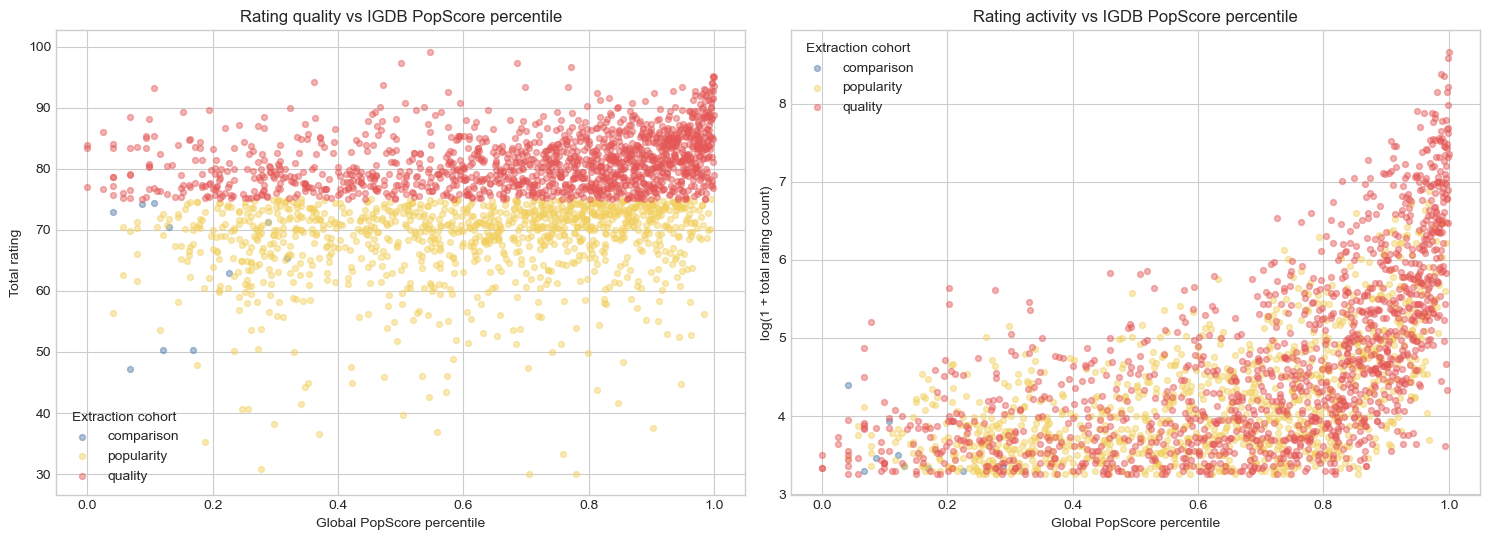

In [65]:
cohort_colors = {"quality": "#E45756", "popularity": "#F2CF5B", "comparison": "#4C78A8"}
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
for cohort, group in popscore_reliable.groupby("extraction_cohort"):
    axes[0].scatter(
        group["custom_interest_percentile"], group["total_rating"],
        s=18, alpha=0.45, label=cohort, color=cohort_colors.get(cohort),
    )
axes[0].set(title="Rating quality vs IGDB PopScore percentile", xlabel="Global PopScore percentile", ylabel="Total rating")
axes[0].legend(title="Extraction cohort")

activity_plot = popscore_reliable.replace([np.inf, -np.inf], np.nan).dropna(subset=["log_total_rating_count", "custom_interest_percentile"])
for cohort, group in activity_plot.groupby("extraction_cohort"):
    axes[1].scatter(
        group["custom_interest_percentile"], group["log_total_rating_count"],
        s=18, alpha=0.45, label=cohort, color=cohort_colors.get(cohort),
    )
axes[1].set(title="Rating activity vs IGDB PopScore percentile", xlabel="Global PopScore percentile", ylabel="log(1 + total rating count)")
axes[1].legend(title="Extraction cohort")
plt.tight_layout()
plt.show()

## 5. Hidden-gem identification

The balanced definition identifies **low-visibility, high-quality candidates within the curated quality cohort**. It requires reliable quality, a main-game record, available PopScore, and visibility at or below the within-year 40th percentile among eligible quality-cohort games. Missing PopScore never means low visibility. These candidates are not estimates of hidden gems in the full game market.

In [66]:
hidden_gem_eligible["hidden_gem_flag"] = (
    (hidden_gem_eligible["total_rating"] >= QUALITY_THRESHOLD)
    & (hidden_gem_eligible["visibility_percentile_eligible_pool"] <= HIDDEN_GEM_VISIBILITY_PERCENTILE)
).astype(int)

hidden_gem_eligible["hidden_gem_conservative"] = (
    (hidden_gem_eligible["total_rating"] >= 85)
    & (hidden_gem_eligible["visibility_percentile_eligible_pool"] <= 0.25)
).astype(int)
hidden_gem_eligible["hidden_gem_broad"] = (
    (hidden_gem_eligible["total_rating"] >= 75)
    & (hidden_gem_eligible["visibility_percentile_eligible_pool"] <= 0.50)
).astype(int)

hidden_gem_threshold_summary = (
    hidden_gem_eligible.groupby("release_year")
    .agg(
        eligible_games=("game_id", "nunique"),
        popscore_25th_percentile=("custom_interest_score", lambda s: s.quantile(0.25)),
        popscore_40th_percentile=("custom_interest_score", lambda s: s.quantile(0.40)),
        popscore_50th_percentile=("custom_interest_score", lambda s: s.quantile(0.50)),
        balanced_hidden_gems=("hidden_gem_flag", "sum"),
    )
    .reset_index()
)

variant_specs = [
    ("Conservative", 85, 0.25, "hidden_gem_conservative"),
    ("Balanced", 80, 0.40, "hidden_gem_flag"),
    ("Broad", 75, 0.50, "hidden_gem_broad"),
]
sensitivity_rows = []
for variant, rating_threshold, visibility_threshold, flag_col in variant_specs:
    selected = hidden_gem_eligible[hidden_gem_eligible[flag_col] == 1]
    sensitivity_rows.append({
        "variant": variant,
        "rating_threshold": rating_threshold,
        "visibility_percentile_threshold": visibility_threshold,
        "eligible_games": len(hidden_gem_eligible),
        "hidden_gem_count": len(selected),
        "hidden_gem_share_of_eligible": len(selected) / len(hidden_gem_eligible) if len(hidden_gem_eligible) else np.nan,
        "median_total_rating": selected["total_rating"].median(),
        "median_visibility_percentile": selected["visibility_percentile_eligible_pool"].median(),
    })
hidden_gem_sensitivity_analysis = pd.DataFrame(sensitivity_rows)

game_labels = run_query("""
SELECT
    g.game_id,
    GROUP_CONCAT(DISTINCT ge.name) AS genres,
    GROUP_CONCAT(DISTINCT th.name) AS themes,
    GROUP_CONCAT(DISTINCT p.name) AS platforms
FROM games g
LEFT JOIN game_genres gg ON g.game_id = gg.game_id
LEFT JOIN genres ge ON gg.genre_id = ge.genre_id
LEFT JOIN game_themes gt ON g.game_id = gt.game_id
LEFT JOIN themes th ON gt.theme_id = th.theme_id
LEFT JOIN game_platforms gp ON g.game_id = gp.game_id
LEFT JOIN platforms p ON gp.platform_id = p.platform_id
GROUP BY g.game_id;
""")

hidden_gem_candidates = (
    hidden_gem_eligible[hidden_gem_eligible["hidden_gem_flag"] == 1]
    .merge(game_labels, on="game_id", how="left")
    .sort_values(["quality_percentile_eligible_pool", "inverse_visibility_percentile", "total_rating_count"], ascending=[False, False, False])
)
hidden_gem_candidate_columns = [
    "game_id", "name", "release_year", "extraction_cohort", "game_type_name",
    "total_rating", "total_rating_count", "custom_interest_score", "custom_interest_percentile",
    "visibility_percentile_eligible_pool", "quality_percentile_eligible_pool", "inverse_visibility_percentile",
    "num_genres", "num_themes", "num_keywords", "num_platforms", "metadata_volume_band",
    "genres", "themes", "platforms",
]
hidden_gem_candidates = hidden_gem_candidates[hidden_gem_candidate_columns]

tables_to_export.update({
    "hidden_gem_candidates": hidden_gem_candidates,
    "hidden_gem_threshold_summary": hidden_gem_threshold_summary,
    "hidden_gem_sensitivity_analysis": hidden_gem_sensitivity_analysis,
})

display(hidden_gem_sensitivity_analysis)
display(hidden_gem_threshold_summary)
display(hidden_gem_candidates.head(25))

,variant,rating_threshold,visibility_percentile_threshold,eligible_games,hidden_gem_count,hidden_gem_share_of_eligible,median_total_rating,median_visibility_percentile
0,Conservative,85,0.250,1364,47,0.034,87.775,0.112
1,Balanced,80,0.400,1364,229,0.168,83.447,0.220
2,Broad,75,0.500,1364,678,0.497,79.474,0.253


,release_year,eligible_games,popscore_25th_percentile,popscore_40th_percentile,popscore_50th_percentile,balanced_hidden_gems
0,2010,74,0.000,0.000,0.000,12
1,2011,79,0.000,0.000,0.000,12
2,2012,89,0.000,0.000,0.000,11
3,2013,90,0.000,0.000,0.000,11
4,2014,80,0.000,0.000,0.000,12
5,2015,97,0.000,0.000,0.000,14
6,2016,113,0.000,0.000,0.000,17
7,2017,104,0.000,0.000,0.000,15
8,2018,107,0.000,0.000,0.000,17
9,2019,119,0.000,0.000,0.000,21


,game_id,name,release_year,extraction_cohort,game_type_name,total_rating,total_rating_count,custom_interest_score,custom_interest_percentile,visibility_percentile_eligible_pool,quality_percentile_eligible_pool,inverse_visibility_percentile,num_genres,num_themes,num_keywords,num_platforms,metadata_volume_band,genres,themes,platforms
192,145327,Town Star,2020,quality,Main Game,93.316,34.000,0.000,0.106,0.022,1.000,0.978,1,1,3,1,Moderate,Simulator,Sandbox,Web browser
175,136482,Undertale Yellow,2023,quality,Main Game,99.211,25.000,0.000,0.548,0.036,1.000,0.964,4,3,4,1,High,"Role-playing (RPG),Turn-based strategy (TBS),A...","Fantasy,Comedy,Drama",PC (Microsoft Windows)
149,117526,Lurkers,2019,quality,Main Game,97.304,36.000,0.000,0.500,0.101,1.000,0.899,7,6,7,2,Very high,"Shooter,Platform,Role-playing (RPG),Simulator,...","Action,Horror,Survival,Sandbox,Open world,Warfare","PC (Microsoft Windows),Web browser"
225,300789,Gakuen Idolmaster,2024,quality,Main Game,97.298,26.000,0.000,0.686,0.181,1.000,0.819,3,1,5,3,High,"Music,Role-playing (RPG),Simulator",Action,"PC (Microsoft Windows),Android,iOS"
193,145439,Escape Simulator,2021,quality,Main Game,93.329,45.000,0.000,0.767,0.338,1.000,0.662,5,1,1,6,High,"Point-and-click,Puzzle,Simulator,Adventure,Indie",Mystery,"Linux,PC (Microsoft Windows),Mac,Xbox One,Stea..."
127,84197,Faith,2017,quality,Main Game,93.683,26.000,0.000,0.472,0.192,0.990,0.808,2,1,5,2,High,"Adventure,Indie",Horror,"PC (Microsoft Windows),Nintendo Switch"
228,318395,Animal Company,2024,quality,Main Game,96.635,74.000,0.000,0.772,0.306,0.986,0.694,1,4,0,2,Very high,Adventure,"Action,Horror,Survival,Comedy","SteamVR,Meta Quest 2"
75,18730,Cataclysm: Dark Days Ahead,2013,quality,Main Game,89.972,25.000,0.000,0.323,0.233,0.978,0.767,4,6,20,4,Very high,"Role-playing (RPG),Simulator,Adventure,Indie","Action,Horror,Survival,Sandbox,Open world,4X (...","Linux,PC (Microsoft Windows),Mac,Web browser"
47,8974,Football Manager 2013,2012,quality,Main Game,89.309,46.000,0.000,0.153,0.107,0.978,0.893,2,0,2,2,Moderate,"Sport,Strategy",None,"PC (Microsoft Windows),Mac"
52,9602,Super Smash Bros. for Wii U,2014,quality,Main Game,89.356,339.000,0.000,0.459,0.400,0.975,0.600,2,4,77,1,Very high,"Fighting,Platform","Action,Fantasy,Science fiction,Party",Wii U


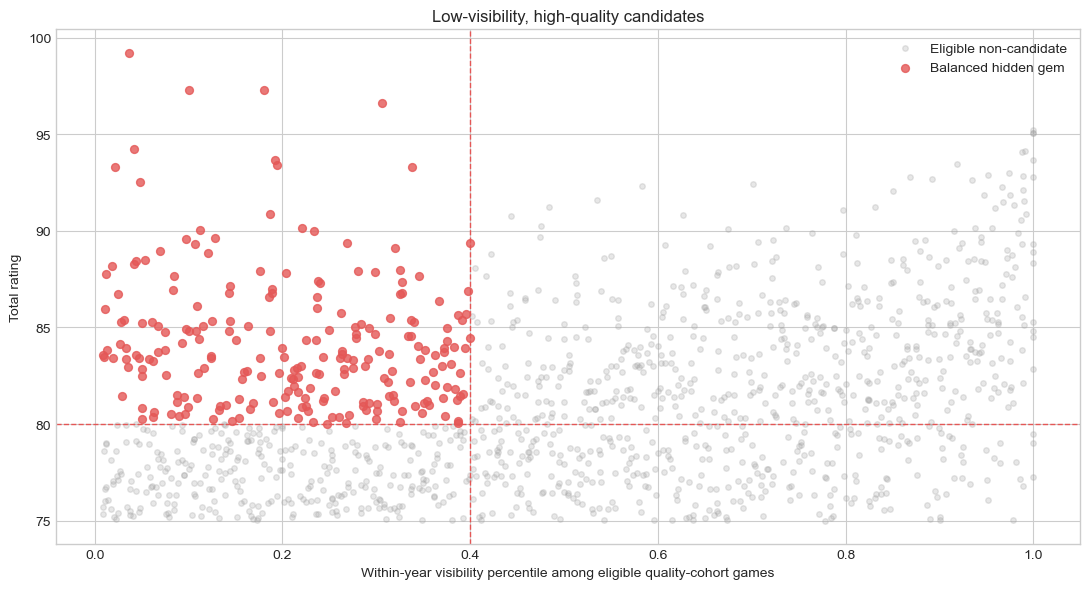

In [67]:
fig, ax = plt.subplots(figsize=(11, 6))
non_gems = hidden_gem_eligible[hidden_gem_eligible["hidden_gem_flag"] == 0]
gems = hidden_gem_eligible[hidden_gem_eligible["hidden_gem_flag"] == 1]
ax.scatter(non_gems["visibility_percentile_eligible_pool"], non_gems["total_rating"], s=16, alpha=0.25, color="#A0A0A0", label="Eligible non-candidate")
ax.scatter(gems["visibility_percentile_eligible_pool"], gems["total_rating"], s=32, alpha=0.8, color="#E45756", label="Balanced hidden gem")
ax.axvline(HIDDEN_GEM_VISIBILITY_PERCENTILE, color="#E45756", linestyle="--", linewidth=1)
ax.axhline(QUALITY_THRESHOLD, color="#E45756", linestyle="--", linewidth=1)
ax.set(title="Low-visibility, high-quality candidates", xlabel="Within-year visibility percentile among eligible quality-cohort games", ylabel="Total rating")
ax.legend()
plt.tight_layout()
plt.show()

## 6. User-versus-critic reception

Positive gaps indicate users rate a game higher than critics; negative gaps indicate critics rate it higher. The main subset requires at least 25 user ratings and 5 critic ratings. Correlation estimates also require at least 25 games in the reporting scope.

,metric,n,value,p_value,correlation_status
0,user_critic_pearson_correlation,1300,0.695,0.000,ok
1,user_critic_spearman_correlation,1300,0.696,0.000,ok
2,median_user_critic_gap,1300,-3.040,NaN,not applicable
3,user_critic_gap_iqr,1300,7.712,NaN,not applicable


,game_id,name,release_year,extraction_cohort,rating,rating_count,aggregated_rating,aggregated_rating_count,total_rating,user_critic_gap,disagreement_direction
0,5574,7 Days to Die,2024,popularity,68.911,206.000,36.125,8.000,52.518,32.786,Users higher
1,55322,Pathologic 2,2019,quality,90.044,93.000,63.200,5.000,76.622,26.844,Users higher
2,1648,James Bond 007: Blood Stone,2010,popularity,70.959,67.000,46.545,9.000,58.752,24.413,Users higher
3,22778,Outward,2019,popularity,78.516,36.000,56.500,5.000,67.508,22.016,Users higher
4,7543,Gods Will Be Watching,2013,popularity,85.783,34.000,64.000,5.000,74.892,21.783,Users higher
5,203259,"Warhammer 40,000: Rogue Trader",2023,quality,88.042,29.000,66.800,5.000,77.421,21.242,Users higher
6,6142,Risen 3: Titan Lords,2014,popularity,71.566,61.000,50.714,7.000,61.140,20.852,Users higher
7,13163,Syberia 3,2017,popularity,64.699,55.000,44.000,8.000,54.350,20.699,Users higher
8,3230,The Night of the Rabbit,2013,quality,87.193,34.000,67.833,5.000,77.513,19.360,Users higher
9,8576,Drakengard 3,2013,popularity,74.618,49.000,56.250,8.000,65.434,18.368,Users higher


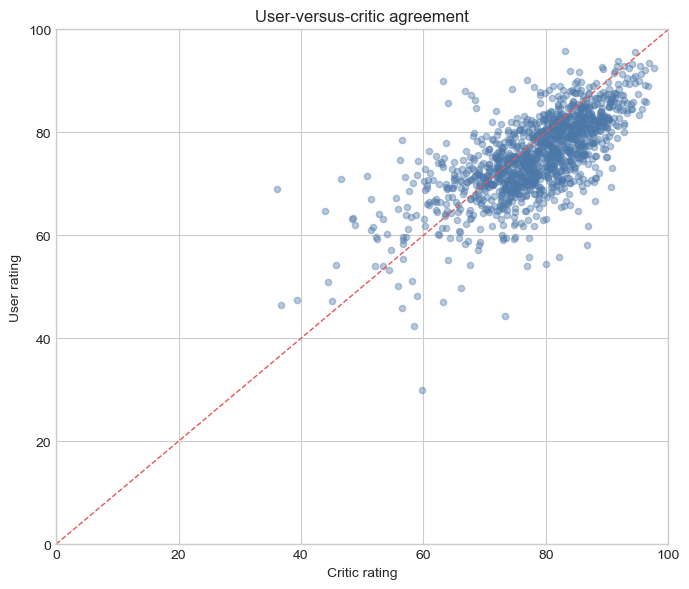

In [68]:
user_critic = diagnostic_game_base[
    diagnostic_game_base["rating"].notna()
    & diagnostic_game_base["aggregated_rating"].notna()
    & (diagnostic_game_base["rating_count"] >= MIN_RATING_COUNT)
    & (diagnostic_game_base["aggregated_rating_count"] >= MIN_CRITIC_COUNT)
].copy()

uc_rows = []
for method in ("pearson", "spearman"):
    n, coefficient, p_value = safe_correlation(user_critic, "rating", "aggregated_rating", method)
    uc_rows.append({
        "metric": f"user_critic_{method}_correlation",
        "n": n,
        "value": coefficient,
        "p_value": p_value,
        "correlation_status": "ok" if n >= MIN_CORRELATION_N and pd.notna(coefficient) else "insufficient sample",
    })
gap_q1 = user_critic["user_critic_gap"].quantile(0.25)
gap_q3 = user_critic["user_critic_gap"].quantile(0.75)
uc_rows.extend([
    {"metric": "median_user_critic_gap", "n": len(user_critic), "value": user_critic["user_critic_gap"].median(), "p_value": np.nan, "correlation_status": "not applicable"},
    {"metric": "user_critic_gap_iqr", "n": len(user_critic), "value": gap_q3 - gap_q1, "p_value": np.nan, "correlation_status": "not applicable"},
])
user_critic_agreement_summary = pd.DataFrame(uc_rows)

user_critic_gap_games = pd.concat([
    user_critic.nlargest(25, "user_critic_gap").assign(disagreement_direction="Users higher"),
    user_critic.nsmallest(25, "user_critic_gap").assign(disagreement_direction="Critics higher"),
], ignore_index=True)[[
    "game_id", "name", "release_year", "extraction_cohort", "rating", "rating_count",
    "aggregated_rating", "aggregated_rating_count", "total_rating", "user_critic_gap", "disagreement_direction",
]]

genre_membership = run_query("""
SELECT DISTINCT gg.game_id, ge.name AS genre_name
FROM game_genres gg JOIN genres ge ON gg.genre_id = ge.genre_id;
""")
user_critic_gap_by_genre = (
    genre_membership.merge(user_critic[["game_id", "user_critic_gap"]], on="game_id", how="inner")
    .groupby("genre_name")
    .agg(game_count=("game_id", "nunique"), median_user_critic_gap=("user_critic_gap", "median"), mean_user_critic_gap=("user_critic_gap", "mean"))
    .reset_index()
    .sort_values("median_user_critic_gap", ascending=False)
)
theme_membership_for_gap = run_query("""
SELECT DISTINCT gt.game_id, th.name AS theme_name
FROM game_themes gt JOIN themes th ON gt.theme_id = th.theme_id;
""")
user_critic_gap_by_theme = (
    theme_membership_for_gap.merge(user_critic[["game_id", "user_critic_gap"]], on="game_id", how="inner")
    .groupby("theme_name")
    .agg(game_count=("game_id", "nunique"), median_user_critic_gap=("user_critic_gap", "median"), mean_user_critic_gap=("user_critic_gap", "mean"))
    .reset_index()
    .sort_values("median_user_critic_gap", ascending=False)
)
user_critic_gap_by_release_year = (
    user_critic.groupby("release_year")
    .agg(game_count=("game_id", "nunique"), median_user_critic_gap=("user_critic_gap", "median"), mean_user_critic_gap=("user_critic_gap", "mean"))
    .reset_index()
)
user_critic_gap_by_cohort = (
    user_critic.groupby("extraction_cohort")
    .agg(game_count=("game_id", "nunique"), median_user_critic_gap=("user_critic_gap", "median"), mean_user_critic_gap=("user_critic_gap", "mean"))
    .reset_index()
)
sensitivity_rows = []
sensitivity_scopes = [("overall", "all", user_critic)]
sensitivity_scopes.extend(("cohort", cohort, group) for cohort, group in user_critic.groupby("extraction_cohort"))
for scope_type, scope_value, subset in sensitivity_scopes:
    n, coefficient, p_value = safe_correlation(subset, "total_rating", "rating", "spearman")
    sensitivity_rows.append({
        "scope_type": scope_type,
        "scope_value": scope_value,
        "game_count": len(subset),
        "total_vs_user_rating_spearman": coefficient,
        "correlation_p_value": p_value,
        "correlation_status": "ok" if n >= MIN_CORRELATION_N and pd.notna(coefficient) else "insufficient sample",
        "median_total_rating": subset["total_rating"].median(),
        "median_user_rating": subset["rating"].median(),
        "combined_high_rated_share": (subset["total_rating"] >= QUALITY_THRESHOLD).mean(),
        "user_high_rated_share": (subset["rating"] >= QUALITY_THRESHOLD).mean(),
    })
user_critic_rating_sensitivity = pd.DataFrame(sensitivity_rows)

tables_to_export.update({
    "user_critic_agreement_summary": user_critic_agreement_summary,
    "user_critic_gap_games": user_critic_gap_games,
    "user_critic_gap_by_genre": user_critic_gap_by_genre,
    "user_critic_gap_by_theme": user_critic_gap_by_theme,
    "user_critic_gap_by_release_year": user_critic_gap_by_release_year,
    "user_critic_gap_by_cohort": user_critic_gap_by_cohort,
    "user_critic_rating_sensitivity": user_critic_rating_sensitivity,
})
display(user_critic_agreement_summary)
display(user_critic_gap_games.head(15))

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(user_critic["aggregated_rating"], user_critic["rating"], s=20, alpha=0.4, color="#4C78A8")
ax.plot([0, 100], [0, 100], linestyle="--", color="#E45756", linewidth=1)
ax.set(xlim=(0, 100), ylim=(0, 100), xlabel="Critic rating", ylabel="User rating", title="User-versus-critic agreement")
plt.tight_layout()
plt.show()

## 7. Cohort-adjusted category association helpers

For each category, the model estimates **quality-cohort enrichment versus the residual comparison cohort** while controlling for release year. The comparison cohort contains games left after quality-selected and popularity-selected games were removed, so this is not a direct model of game quality and must not be interpreted as a market-wide genre or theme effect. Odds ratios above 1 indicate higher odds of quality-cohort membership under this curated extraction design. Benjamini-Hochberg correction controls the false discovery rate across each family of tests.

In [69]:
association_universe = diagnostic_game_base[
    diagnostic_game_base["extraction_cohort"].isin(["quality", "comparison"])
][["game_id", "release_year", "extraction_cohort"]].drop_duplicates().copy()
association_universe["cohort_quality"] = (association_universe["extraction_cohort"] == "quality").astype(int)


def fit_category_associations(membership, category_col, category_type, min_group_size):
    membership = membership[["game_id", category_col]].dropna().drop_duplicates()
    eligible_counts = membership[membership["game_id"].isin(association_universe["game_id"])].groupby(category_col)["game_id"].nunique()
    categories = eligible_counts[eligible_counts >= min_group_size].index
    rows = []
    for category in categories:
        member_ids = set(membership.loc[membership[category_col] == category, "game_id"])
        model_data = association_universe.copy()
        model_data["has_category"] = model_data["game_id"].isin(member_ids).astype(int)
        quality_with = int(((model_data["cohort_quality"] == 1) & (model_data["has_category"] == 1)).sum())
        comparison_with = int(((model_data["cohort_quality"] == 0) & (model_data["has_category"] == 1)).sum())
        row = {
            "category_type": category_type,
            "category_name": category,
            "estimand": "quality-cohort enrichment vs residual comparison cohort",
            "category_game_count": int(model_data["has_category"].sum()),
            "quality_games_with_category": quality_with,
            "comparison_games_with_category": comparison_with,
            "odds_ratio": np.nan,
            "odds_ratio_ci_low": np.nan,
            "odds_ratio_ci_high": np.nan,
            "p_value": np.nan,
            "model_status": "not fit",
        }
        if model_data["has_category"].nunique() < 2 or quality_with == 0 or comparison_with == 0:
            row["model_status"] = "insufficient variation"
            rows.append(row)
            continue
        try:
            model = smf.glm(
                "cohort_quality ~ has_category + C(release_year)",
                data=model_data,
                family=sm.families.Binomial(),
            ).fit(cov_type="HC3")
            coefficient = model.params["has_category"]
            ci_low, ci_high = model.conf_int().loc["has_category"]
            row.update({
                "odds_ratio": float(np.exp(coefficient)),
                "odds_ratio_ci_low": float(np.exp(ci_low)),
                "odds_ratio_ci_high": float(np.exp(ci_high)),
                "p_value": float(model.pvalues["has_category"]),
                "model_status": "ok",
            })
        except Exception as exc:
            row["model_status"] = f"failed: {type(exc).__name__}"
        rows.append(row)
    result = pd.DataFrame(rows)
    if result.empty:
        return result
    result["adjusted_p_value"] = benjamini_hochberg(result["p_value"])
    result["fdr_significant"] = result["adjusted_p_value"] < MULTIPLE_TEST_ALPHA
    return result.sort_values(["adjusted_p_value", "odds_ratio"], ascending=[True, False])


def build_category_summary(membership, category_col, min_group_size, effects=None):
    membership = membership[["game_id", category_col]].dropna().drop_duplicates()
    reliable_members = membership.merge(
        rating_reliable[["game_id", "total_rating", "total_rating_count", "high_rated_flag", "extraction_cohort"]],
        on="game_id", how="inner",
    )
    summary = (
        reliable_members.groupby(category_col)
        .agg(
            game_count=("game_id", "nunique"),
            median_total_rating=("total_rating", "median"),
            mean_total_rating=("total_rating", "mean"),
            rating_q1=("total_rating", lambda s: s.quantile(0.25)),
            rating_q3=("total_rating", lambda s: s.quantile(0.75)),
            median_total_rating_count=("total_rating_count", "median"),
            high_rated_count=("high_rated_flag", "sum"),
            high_rated_share=("high_rated_flag", "mean"),
        )
        .reset_index()
    )
    summary["rating_iqr"] = summary["rating_q3"] - summary["rating_q1"]

    cohort_counts_local = (
        reliable_members.groupby([category_col, "extraction_cohort"])["game_id"].nunique().unstack(fill_value=0)
        .add_suffix("_cohort_games").reset_index()
    )
    summary = summary.merge(cohort_counts_local, on=category_col, how="left")

    hidden_members = membership.merge(
        hidden_gem_eligible[["game_id", "hidden_gem_flag"]], on="game_id", how="inner"
    )
    hidden_summary = (
        hidden_members.groupby(category_col)
        .agg(hidden_gem_eligible_games=("game_id", "nunique"), hidden_gem_count=("hidden_gem_flag", "sum"), hidden_gem_share=("hidden_gem_flag", "mean"))
        .reset_index()
    )
    summary = summary.merge(hidden_summary, on=category_col, how="left")
    summary["low_sample_flag"] = summary["game_count"] < min_group_size

    if effects is not None and not effects.empty:
        effect_columns = [
            "category_name", "estimand", "odds_ratio", "odds_ratio_ci_low", "odds_ratio_ci_high",
            "p_value", "adjusted_p_value", "fdr_significant", "model_status",
        ]
        summary = summary.merge(
            effects[effect_columns].rename(columns={"category_name": category_col}),
            on=category_col, how="left",
        )
    return summary.sort_values(["low_sample_flag", "median_total_rating", "game_count"], ascending=[True, False, False])

## 8. Genre, theme, and genre-theme diagnostics

In [70]:
theme_membership = run_query("""
SELECT DISTINCT gt.game_id, th.name AS theme_name
FROM game_themes gt JOIN themes th ON gt.theme_id = th.theme_id;
""")
genre_theme_membership = run_query("""
SELECT DISTINCT gg.game_id, ge.name AS genre_name, th.name AS theme_name,
       ge.name || ' | ' || th.name AS genre_theme_name
FROM game_genres gg
JOIN genres ge ON gg.genre_id = ge.genre_id
JOIN game_themes gt ON gg.game_id = gt.game_id
JOIN themes th ON gt.theme_id = th.theme_id;
""")

genre_effects = fit_category_associations(genre_membership, "genre_name", "genre", MIN_GROUP_SIZE)
theme_effects = fit_category_associations(theme_membership, "theme_name", "theme", MIN_GROUP_SIZE)
genre_theme_effects = fit_category_associations(
    genre_theme_membership[["game_id", "genre_theme_name"]],
    "genre_theme_name", "genre_theme", MIN_INTERACTION_GROUP_SIZE,
)

genre_rating_summary = build_category_summary(genre_membership, "genre_name", MIN_GROUP_SIZE, genre_effects)
theme_rating_summary = build_category_summary(theme_membership, "theme_name", MIN_GROUP_SIZE, theme_effects)
genre_theme_rating_summary = build_category_summary(
    genre_theme_membership[["game_id", "genre_theme_name"]],
    "genre_theme_name", MIN_INTERACTION_GROUP_SIZE, genre_theme_effects,
)
genre_theme_names = genre_theme_membership[["genre_theme_name", "genre_name", "theme_name"]].drop_duplicates()
genre_theme_rating_summary = genre_theme_rating_summary.merge(genre_theme_names, on="genre_theme_name", how="left")

hidden_gem_by_genre = genre_rating_summary[[
    "genre_name", "hidden_gem_eligible_games", "hidden_gem_count", "hidden_gem_share", "game_count"
]].sort_values(["hidden_gem_count", "hidden_gem_share"], ascending=False)
hidden_gem_by_theme = theme_rating_summary[[
    "theme_name", "hidden_gem_eligible_games", "hidden_gem_count", "hidden_gem_share", "game_count"
]].sort_values(["hidden_gem_count", "hidden_gem_share"], ascending=False)

tables_to_export.update({
    "genre_rating_summary": genre_rating_summary,
    "theme_rating_summary": theme_rating_summary,
    "genre_theme_rating_summary": genre_theme_rating_summary,
    "hidden_gem_by_genre": hidden_gem_by_genre,
    "hidden_gem_by_theme": hidden_gem_by_theme,
})

display(genre_rating_summary.head(20))
display(theme_rating_summary.head(20))
display(genre_theme_rating_summary.head(25))

,genre_name,game_count,median_total_rating,mean_total_rating,rating_q1,rating_q3,median_total_rating_count,high_rated_count,high_rated_share,rating_iqr,comparison_cohort_games,popularity_cohort_games,quality_cohort_games,hidden_gem_eligible_games,hidden_gem_count,hidden_gem_share,low_sample_flag,estimand,odds_ratio,odds_ratio_ci_low,odds_ratio_ci_high,p_value,adjusted_p_value,fdr_significant,model_status
21,Turn-based strategy (TBS),154,79.181,78.080,74.189,83.123,52.500,69.000,0.448,8.935,2,45,107,105,21,0.200,False,quality-cohort enrichment vs residual comparis...,4.646,3.635,5.939,0.000,0.000,True,ok
22,Visual Novel,79,78.665,78.048,72.582,83.648,49.000,34.000,0.430,11.066,1,25,53,51,12,0.235,False,quality-cohort enrichment vs residual comparis...,0.551,0.414,0.733,0.000,0.000,True,ok
7,Music,61,78.165,77.401,73.719,81.825,39.000,24.000,0.393,8.106,1,17,43,42,18,0.429,False,quality-cohort enrichment vs residual comparis...,1.537,1.100,2.148,0.012,0.015,True,ok
9,Platform,388,77.419,76.880,72.486,82.350,70.000,143.000,0.369,9.864,1,147,240,233,49,0.210,False,quality-cohort enrichment vs residual comparis...,2.429,2.075,2.843,0.000,0.000,True,ok
11,Puzzle,530,77.290,76.752,72.561,81.366,61.000,176.000,0.332,8.805,6,194,330,314,60,0.191,False,quality-cohort enrichment vs residual comparis...,1.780,1.553,2.040,0.000,0.000,True,ok
10,Point-and-click,154,77.109,77.003,73.105,81.288,53.500,48.000,0.312,8.183,1,53,100,91,16,0.176,False,quality-cohort enrichment vs residual comparis...,1.972,1.571,2.476,0.000,0.000,True,ok
14,Real Time Strategy (RTS),72,76.865,76.654,74.488,81.949,65.000,24.000,0.333,7.462,1,20,51,47,6,0.128,False,quality-cohort enrichment vs residual comparis...,4.056,2.877,5.718,0.000,0.000,True,ok
15,Role-playing (RPG),746,76.780,76.098,71.252,82.317,66.000,275.000,0.369,11.066,4,312,430,421,66,0.157,False,quality-cohort enrichment vs residual comparis...,2.862,2.518,3.252,0.000,0.000,True,ok
20,Tactical,144,76.779,75.837,71.187,81.702,69.500,55.000,0.382,10.515,2,58,84,81,14,0.173,False,quality-cohort enrichment vs residual comparis...,7.370,5.449,9.970,0.000,0.000,True,ok
18,Sport,177,76.762,75.834,72.347,81.098,51.000,53.000,0.299,8.751,5,65,107,98,38,0.388,False,quality-cohort enrichment vs residual comparis...,1.258,1.017,1.557,0.035,0.040,True,ok


,theme_name,game_count,median_total_rating,mean_total_rating,rating_q1,rating_q3,median_total_rating_count,high_rated_count,high_rated_share,rating_iqr,comparison_cohort_games,popularity_cohort_games,quality_cohort_games,hidden_gem_eligible_games,hidden_gem_count,hidden_gem_share,low_sample_flag,estimand,odds_ratio,odds_ratio_ci_low,odds_ratio_ci_high,p_value,adjusted_p_value,fdr_significant,model_status
4,Drama,151,79.761,78.695,74.466,83.553,101.000,69.000,0.457,9.087,1,41,109,103,15,0.146,False,quality-cohort enrichment vs residual comparis...,3.556,2.820,4.486,0.000,0.000,True,ok
15,Romance,32,78.340,76.422,72.708,81.613,61.000,11.000,0.344,8.905,0,12,20,20,4,0.200,False,quality-cohort enrichment vs residual comparis...,0.390,0.248,0.615,0.000,0.000,True,ok
11,Mystery,223,77.667,76.773,72.734,82.020,63.000,79.000,0.354,9.286,1,83,139,135,22,0.163,False,quality-cohort enrichment vs residual comparis...,3.457,2.810,4.254,0.000,0.000,True,ok
7,Fantasy,786,77.317,76.389,71.252,82.498,74.000,289.000,0.368,11.246,4,305,477,468,61,0.130,False,quality-cohort enrichment vs residual comparis...,5.006,4.397,5.700,0.000,0.000,True,ok
12,Non-fiction,92,77.275,76.105,73.502,80.044,68.500,24.000,0.261,6.541,2,28,62,58,12,0.207,False,quality-cohort enrichment vs residual comparis...,7.080,4.994,10.038,0.000,0.000,True,ok
16,Sandbox,195,76.981,76.598,72.505,81.724,94.000,67.000,0.344,9.219,0,78,117,116,15,0.129,False,quality-cohort enrichment vs residual comparis...,8.489,6.518,11.057,0.000,0.000,True,ok
2,Business,45,76.981,77.416,73.672,82.839,64.000,15.000,0.333,9.167,0,16,29,29,6,0.207,False,quality-cohort enrichment vs residual comparis...,2.223,1.469,3.366,0.000,0.000,True,ok
17,Science fiction,595,76.937,76.287,72.210,81.969,87.000,209.000,0.351,9.758,5,226,364,354,48,0.136,False,quality-cohort enrichment vs residual comparis...,5.465,4.726,6.320,0.000,0.000,True,ok
13,Open world,344,76.639,75.827,70.535,82.393,142.500,126.000,0.366,11.858,0,150,194,193,15,0.078,False,quality-cohort enrichment vs residual comparis...,16.214,12.689,20.719,0.000,0.000,True,ok
20,Thriller,119,76.245,75.413,70.501,81.682,84.000,40.000,0.336,11.180,1,54,64,62,7,0.113,False,quality-cohort enrichment vs residual comparis...,8.953,6.251,12.822,0.000,0.000,True,ok


,genre_theme_name,game_count,median_total_rating,mean_total_rating,rating_q1,rating_q3,median_total_rating_count,high_rated_count,high_rated_share,rating_iqr,comparison_cohort_games,popularity_cohort_games,quality_cohort_games,hidden_gem_eligible_games,hidden_gem_count,hidden_gem_share,low_sample_flag,estimand,odds_ratio,odds_ratio_ci_low,odds_ratio_ci_high,p_value,adjusted_p_value,fdr_significant,model_status,genre_name,theme_name
0,Role-playing (RPG) | Drama,50,82.662,81.453,76.339,85.437,101.500,30.000,0.600,9.097,0,9,41,38.000,7.000,0.184,False,quality-cohort enrichment vs residual comparis...,11.211,7.008,17.937,0.000,0.000,True,ok,Role-playing (RPG),Drama
1,Turn-based strategy (TBS) | Science fiction,48,80.831,78.703,75.473,82.851,67.000,28.000,0.583,7.378,1,11,36,35.000,4.000,0.114,False,quality-cohort enrichment vs residual comparis...,11.851,7.011,20.032,0.000,0.000,True,ok,Turn-based strategy (TBS),Science fiction
2,Tactical | Historical,26,80.123,78.442,70.418,84.703,121.000,13.000,0.500,14.285,0,8,18,17.000,1.000,0.059,False,quality-cohort enrichment vs residual comparis...,22.219,8.651,57.070,0.000,0.000,True,ok,Tactical,Historical
3,Point-and-click | Drama,36,79.848,78.314,74.682,82.609,73.000,15.000,0.417,7.928,0,9,27,24.000,3.000,0.125,False,quality-cohort enrichment vs residual comparis...,13.571,7.182,25.644,0.000,0.000,True,ok,Point-and-click,Drama
4,Puzzle | Drama,37,79.845,79.066,75.866,82.312,73.000,16.000,0.432,6.447,0,9,28,25.000,2.000,0.080,False,quality-cohort enrichment vs residual comparis...,8.452,4.935,14.477,0.000,0.000,True,ok,Puzzle,Drama
5,Tactical | Fantasy,51,79.802,78.592,74.105,84.231,47.000,25.000,0.490,10.126,0,16,35,34.000,10.000,0.294,False,quality-cohort enrichment vs residual comparis...,14.019,7.996,24.579,0.000,0.000,True,ok,Tactical,Fantasy
6,Visual Novel | Mystery,29,79.663,78.607,72.449,84.210,51.000,14.000,0.483,11.761,1,8,20,19.000,5.000,0.263,False,quality-cohort enrichment vs residual comparis...,1.374,0.850,2.221,0.195,0.222,False,ok,Visual Novel,Mystery
7,Turn-based strategy (TBS) | Fantasy,101,79.464,78.420,74.435,83.517,56.000,46.000,0.455,9.082,0,27,74,73.000,17.000,0.233,False,quality-cohort enrichment vs residual comparis...,8.551,6.127,11.934,0.000,0.000,True,ok,Turn-based strategy (TBS),Fantasy
8,Adventure | Drama,134,79.322,78.487,73.848,83.567,100.500,59.000,0.440,9.718,1,38,95,90.000,11.000,0.122,False,quality-cohort enrichment vs residual comparis...,7.695,5.772,10.259,0.000,0.000,True,ok,Adventure,Drama
9,Visual Novel | Thriller,20,79.273,77.788,73.541,82.885,75.000,10.000,0.500,9.344,1,5,14,14.000,2.000,0.143,False,quality-cohort enrichment vs residual comparis...,7.129,3.468,14.654,0.000,0.000,True,ok,Visual Novel,Thriller


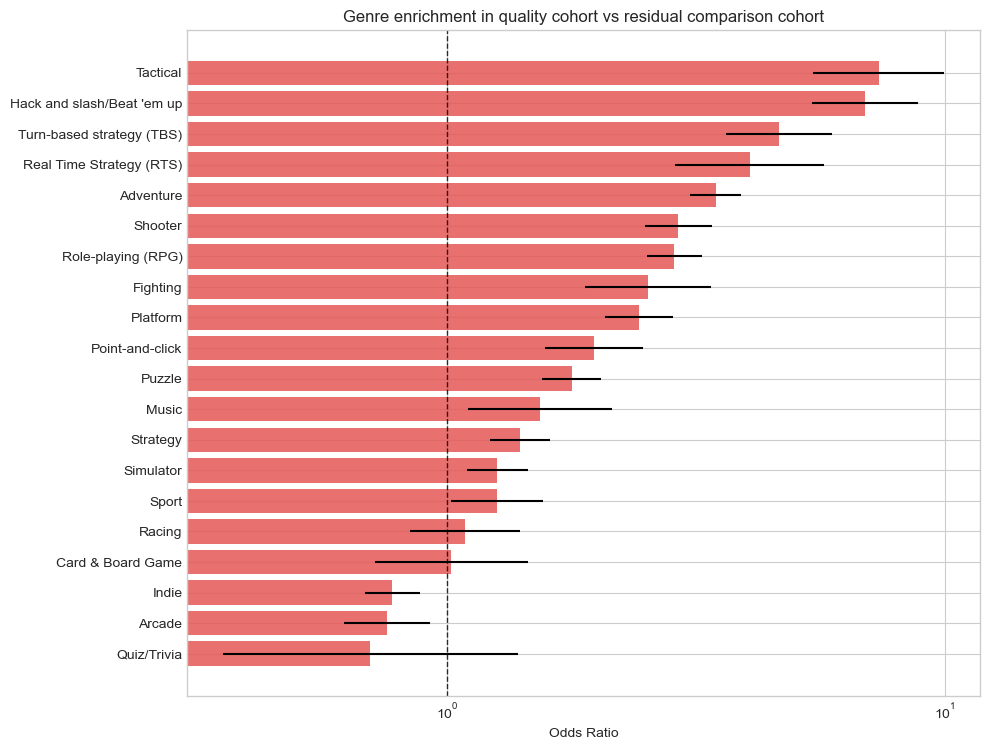

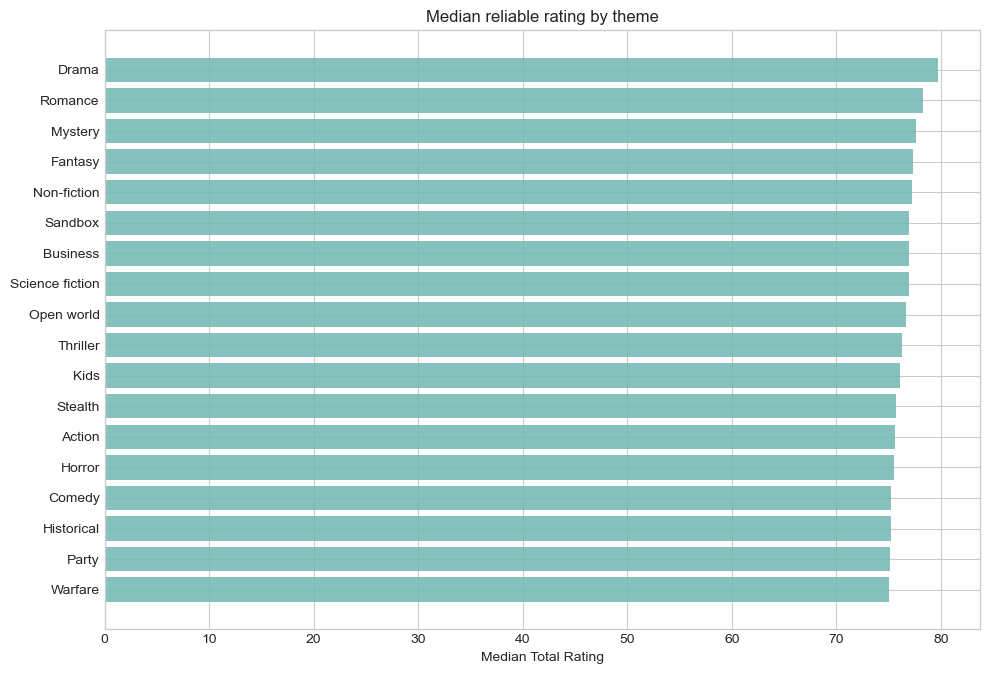

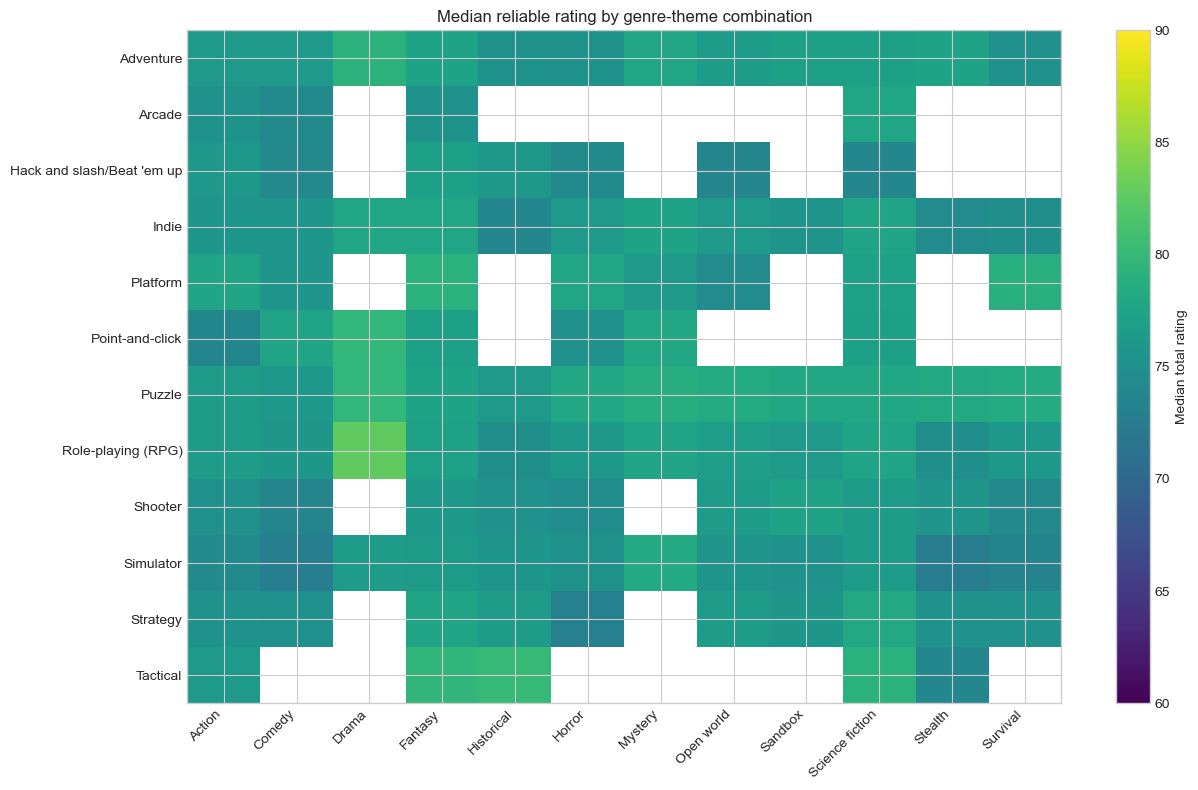

In [71]:
genre_effect_plot = genre_rating_summary.query("model_status == 'ok'").copy()
plot_barh(
    genre_effect_plot, "genre_name", "odds_ratio",
    "Genre enrichment in quality cohort vs residual comparison cohort",
    top_n=20, color="#E45756", error_cols=("odds_ratio_ci_low", "odds_ratio_ci_high"),
    reference_line=1.0, log_x=True,
)

plot_barh(
    theme_rating_summary.query("low_sample_flag == False"),
    "theme_name", "median_total_rating", "Median reliable rating by theme", top_n=18, color="#72B7B2",
)

heatmap_source = genre_theme_rating_summary.query("low_sample_flag == False").copy()
top_genres_heat = heatmap_source.groupby("genre_name")["game_count"].sum().nlargest(12).index
top_themes_heat = heatmap_source.groupby("theme_name")["game_count"].sum().nlargest(12).index
heatmap_data = (
    heatmap_source[heatmap_source["genre_name"].isin(top_genres_heat) & heatmap_source["theme_name"].isin(top_themes_heat)]
    .pivot(index="genre_name", columns="theme_name", values="median_total_rating")
)
if not heatmap_data.empty:
    fig, ax = plt.subplots(figsize=(13, 8))
    image = ax.imshow(heatmap_data, aspect="auto", cmap="viridis", vmin=60, vmax=90)
    ax.set_xticks(range(len(heatmap_data.columns)), heatmap_data.columns, rotation=45, ha="right")
    ax.set_yticks(range(len(heatmap_data.index)), heatmap_data.index)
    ax.set_title("Median reliable rating by genre-theme combination")
    fig.colorbar(image, ax=ax, label="Median total rating")
    plt.tight_layout()
    plt.show()

## 9. Platform reach and platform-group diagnostics

Platform groups overlap because games can appear on multiple platforms and families.

,platform_reach_band,extraction_cohort,game_count,popscore_covered_games,hidden_gem_eligible_games,hidden_gem_count,median_custom_interest_percentile,rated_reliable_games,median_total_rating,median_total_rating_count,high_rated_share,hidden_gem_share
0,1 platform,comparison,6812,155,0,0.000,0.041,4,70.522,27.000,0.000,NaN
1,1 platform,popularity,615,615,0,0.000,0.343,112,69.833,43.500,0.000,NaN
2,1 platform,quality,198,189,189,49.000,0.686,198,81.614,72.000,0.646,0.259
3,2-3 platforms,comparison,2994,159,0,0.000,0.056,9,72.266,37.000,0.000,NaN
4,2-3 platforms,popularity,921,921,0,0.000,0.407,312,69.831,53.000,0.000,NaN
5,2-3 platforms,quality,381,360,360,60.000,0.779,381,80.471,85.000,0.549,0.167
6,4-6 platforms,comparison,682,113,0,0.000,0.098,13,61.132,28.000,0.000,NaN
7,4-6 platforms,popularity,1121,1121,0,0.000,0.512,455,70.248,56.000,0.000,NaN
8,4-6 platforms,quality,552,535,535,84.000,0.789,552,80.068,78.000,0.511,0.157
9,7+ platforms,comparison,94,30,0,0.000,0.097,3,70.237,46.000,0.000,NaN


,platform_family,game_count,median_total_rating,mean_total_rating,rating_q1,rating_q3,median_total_rating_count,high_rated_count,high_rated_share,rating_iqr,comparison_cohort_games,popularity_cohort_games,quality_cohort_games,hidden_gem_eligible_games,hidden_gem_count,hidden_gem_share,low_sample_flag
1,Nintendo,1170,76.832,76.251,71.731,81.685,60.000,389.000,0.332,9.953,6,460,704,686,128,0.187,False
0,Linux,973,76.276,75.358,70.914,80.959,68.000,284.000,0.292,10.045,14,400,559,540,71,0.131,False
2,Other / Unknown,2198,76.033,75.119,70.612,81.082,65.000,649.000,0.295,10.470,24,960,1214,1175,185,0.157,False
3,PlayStation,1740,76.012,75.339,70.849,81.108,73.000,517.000,0.297,10.260,14,764,962,932,129,0.138,False
5,Xbox,1583,75.943,75.123,70.675,80.971,77.000,460.000,0.291,10.296,12,706,865,842,111,0.132,False
4,Sega,2,77.487,77.487,76.368,78.606,49.000,0.000,0.000,2.238,0,0,2,2,0,0.000,True


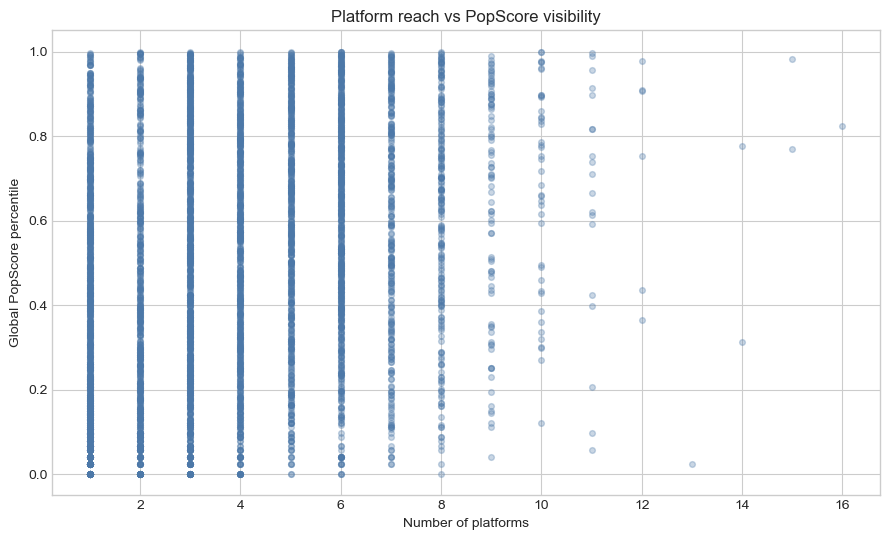

In [72]:
diagnostic_game_base["platform_reach_band"] = pd.cut(
    diagnostic_game_base["num_platforms"],
    bins=[0, 1, 3, 6, np.inf],
    labels=["1 platform", "2-3 platforms", "4-6 platforms", "7+ platforms"],
    include_lowest=True,
)
rating_reliable = diagnostic_game_base[diagnostic_game_base["rating_reliable_flag"] == 1].copy()
platform_analysis_base = diagnostic_game_base.merge(
    hidden_gem_eligible[["game_id", "hidden_gem_flag"]], on="game_id", how="left"
)

platform_reach_coverage_summary = (
    platform_analysis_base.groupby(["platform_reach_band", "extraction_cohort"], observed=True)
    .agg(
        game_count=("game_id", "nunique"),
        popscore_covered_games=("popscore_available_flag", "sum"),
        hidden_gem_eligible_games=("hidden_gem_flag", "count"),
        hidden_gem_count=("hidden_gem_flag", "sum"),
        median_custom_interest_percentile=("custom_interest_percentile", "median"),
    )
    .reset_index()
)
platform_reach_rating_summary = (
    platform_analysis_base[platform_analysis_base["rating_reliable_flag"] == 1]
    .groupby(["platform_reach_band", "extraction_cohort"], observed=True)
    .agg(
        rated_reliable_games=("game_id", "nunique"),
        median_total_rating=("total_rating", "median"),
        median_total_rating_count=("total_rating_count", "median"),
        high_rated_share=("high_rated_flag", "mean"),
    )
    .reset_index()
)
platform_reach_summary = platform_reach_coverage_summary.merge(
    platform_reach_rating_summary,
    on=["platform_reach_band", "extraction_cohort"],
    how="left",
)
platform_reach_summary["hidden_gem_share"] = platform_reach_summary["hidden_gem_count"] / platform_reach_summary["hidden_gem_eligible_games"].replace(0, np.nan)

platform_family_membership = run_query("""
SELECT DISTINCT gp.game_id, COALESCE(pf.name, 'Other / Unknown') AS platform_family
FROM game_platforms gp
JOIN platforms p ON gp.platform_id = p.platform_id
LEFT JOIN platform_families pf ON p.platform_family_id = pf.platform_family_id;
""")
platform_type_membership = run_query("""
SELECT DISTINCT gp.game_id, COALESCE(pt.name, 'Unknown') AS platform_type
FROM game_platforms gp
JOIN platforms p ON gp.platform_id = p.platform_id
LEFT JOIN platform_types pt ON p.platform_type_id = pt.platform_type_id;
""")

platform_family_rating_summary = build_category_summary(platform_family_membership, "platform_family", 20)
platform_type_rating_summary = build_category_summary(platform_type_membership, "platform_type", 20)
hidden_gem_by_platform_family = platform_family_rating_summary[[
    "platform_family", "hidden_gem_eligible_games", "hidden_gem_count", "hidden_gem_share", "game_count"
]].sort_values(["hidden_gem_count", "hidden_gem_share"], ascending=False)

platform_visibility_correlation = correlation_table(
    diagnostic_game_base[diagnostic_game_base["popscore_available_flag"] == 1],
    "num_platforms", "custom_interest_percentile",
)

tables_to_export.update({
    "platform_reach_summary": platform_reach_summary,
    "platform_family_rating_summary": platform_family_rating_summary,
    "platform_type_rating_summary": platform_type_rating_summary,
    "hidden_gem_by_platform_family": hidden_gem_by_platform_family,
})
display(platform_reach_summary)
display(platform_family_rating_summary)

platform_plot = diagnostic_game_base[diagnostic_game_base["popscore_available_flag"] == 1]
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.scatter(platform_plot["num_platforms"], platform_plot["custom_interest_percentile"], s=17, alpha=0.3, color="#4C78A8")
ax.set(title="Platform reach vs PopScore visibility", xlabel="Number of platforms", ylabel="Global PopScore percentile")
plt.tight_layout()
plt.show()

## 10. Developer and publisher diagnostics

Company-level results are exploratory. The adjusted models require at least 10 quality/comparison games per company and use the same release-year controls and FDR correction.

In [73]:
developer_membership = run_query("""
SELECT DISTINCT ic.game_id, c.name AS developer_name
FROM involved_companies ic JOIN companies c ON ic.company_id = c.company_id
WHERE ic.developer = 1;
""")
publisher_membership = run_query("""
SELECT DISTINCT ic.game_id, c.name AS publisher_name
FROM involved_companies ic JOIN companies c ON ic.company_id = c.company_id
WHERE ic.publisher = 1;
""")

developer_effects = fit_category_associations(developer_membership, "developer_name", "developer", MIN_COMPANY_GROUP_SIZE)
publisher_effects = fit_category_associations(publisher_membership, "publisher_name", "publisher", MIN_COMPANY_GROUP_SIZE)
developer_rating_summary = build_category_summary(developer_membership, "developer_name", MIN_COMPANY_GROUP_SIZE, developer_effects)
publisher_rating_summary = build_category_summary(publisher_membership, "publisher_name", MIN_COMPANY_GROUP_SIZE, publisher_effects)

tables_to_export.update({
    "developer_rating_summary": developer_rating_summary,
    "publisher_rating_summary": publisher_rating_summary,
})
display(developer_rating_summary.query("low_sample_flag == False").head(25))
display(publisher_rating_summary.query("low_sample_flag == False").head(25))

,developer_name,game_count,median_total_rating,mean_total_rating,rating_q1,rating_q3,median_total_rating_count,high_rated_count,high_rated_share,rating_iqr,comparison_cohort_games,popularity_cohort_games,quality_cohort_games,hidden_gem_eligible_games,hidden_gem_count,hidden_gem_share,low_sample_flag,estimand,odds_ratio,odds_ratio_ci_low,odds_ratio_ci_high,p_value,adjusted_p_value,fdr_significant,model_status
1186,Sports Interactive,14,83.756,83.652,82.190,86.527,46.000,12.000,0.857,4.336,0,1,13,12.000,10.000,0.833,False,quality-cohort enrichment vs residual comparis...,NaN,NaN,NaN,NaN,NaN,False,insufficient variation
1084,Ryu Ga Gotoku Studios,10,83.088,82.466,82.169,84.722,87.000,8.000,0.800,2.553,0,0,10,10.000,0.000,0.000,False,quality-cohort enrichment vs residual comparis...,NaN,NaN,NaN,NaN,NaN,False,insufficient variation
902,Obsidian Entertainment,10,81.835,79.723,77.486,83.432,141.500,7.000,0.700,5.946,0,2,8,8.000,0.000,0.000,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1182,Spike Chunsoft,12,81.123,77.127,70.471,85.337,87.500,7.000,0.583,14.866,0,5,7,7.000,1.000,0.143,False,quality-cohort enrichment vs residual comparis...,12.777,3.619,45.111,0.000,0.000,True,ok
862,Nintendo,12,81.094,80.451,74.816,85.399,181.000,7.000,0.583,10.583,0,3,9,9.000,2.000,0.222,False,quality-cohort enrichment vs residual comparis...,7.786,3.059,19.814,0.000,0.000,True,ok
1308,The Creative Assembly,10,81.035,81.059,77.389,85.048,106.500,7.000,0.700,7.659,0,1,9,8.000,0.000,0.000,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
516,Game Freak,14,80.831,78.255,76.962,82.321,241.000,9.000,0.643,5.359,0,3,11,11.000,0.000,0.000,False,quality-cohort enrichment vs residual comparis...,NaN,NaN,NaN,NaN,NaN,False,insufficient variation
976,PlatinumGames,11,80.007,75.704,68.244,85.511,88.000,6.000,0.545,17.267,1,3,7,6.000,0.000,0.000,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
98,Atlus,12,79.685,81.979,78.977,84.716,50.000,5.000,0.417,5.739,0,0,12,12.000,2.000,0.167,False,quality-cohort enrichment vs residual comparis...,85.458,10.733,680.409,0.000,0.000,True,ok
394,EA Canada,17,78.971,77.895,77.382,80.147,48.000,6.000,0.353,2.765,0,3,14,12.000,5.000,0.417,False,quality-cohort enrichment vs residual comparis...,38.083,11.130,130.308,0.000,0.000,True,ok


,publisher_name,game_count,median_total_rating,mean_total_rating,rating_q1,rating_q3,median_total_rating_count,high_rated_count,high_rated_share,rating_iqr,comparison_cohort_games,popularity_cohort_games,quality_cohort_games,hidden_gem_eligible_games,hidden_gem_count,hidden_gem_share,low_sample_flag,estimand,odds_ratio,odds_ratio_ci_low,odds_ratio_ci_high,p_value,adjusted_p_value,fdr_significant,model_status
910,Take-Two Interactive,13,83.880,80.065,73.661,86.546,"1,037.000",7.000,0.538,12.885,0,4,9,9.000,0.000,0.000,False,quality-cohort enrichment vs residual comparis...,36.615,7.651,175.220,0.000,0.000,True,ok
859,Sony Interactive Entertainment,37,83.500,82.134,75.757,88.429,204.000,24.000,0.649,12.671,1,7,29,29.000,2.000,0.069,False,quality-cohort enrichment vs residual comparis...,35.559,14.359,88.060,0.000,0.000,True,ok
1049,Xbox Game Studios,18,83.270,80.797,76.479,86.333,151.500,10.000,0.556,9.854,0,3,15,15.000,0.000,0.000,False,quality-cohort enrichment vs residual comparis...,61.617,13.873,273.672,0.000,0.000,True,ok
817,Sega Games,17,83.153,80.029,81.162,85.011,62.000,13.000,0.765,3.849,0,3,14,13.000,3.000,0.231,False,quality-cohort enrichment vs residual comparis...,13.100,5.235,32.780,0.000,0.000,True,ok
870,Spike Chunsoft,19,82.142,80.935,76.524,85.606,174.000,13.000,0.684,9.082,0,5,14,14.000,1.000,0.071,False,quality-cohort enrichment vs residual comparis...,33.019,9.294,117.314,0.000,0.000,True,ok
623,NIS America,15,82.142,79.426,74.530,84.443,45.000,9.000,0.600,9.913,0,4,11,11.000,3.000,0.273,False,quality-cohort enrichment vs residual comparis...,11.393,4.378,29.650,0.000,0.000,True,ok
691,PLAYISM,11,81.372,79.224,79.300,84.600,72.000,8.000,0.727,5.299,0,2,9,9.000,3.000,0.333,False,quality-cohort enrichment vs residual comparis...,9.447,3.512,25.415,0.000,0.000,True,ok
636,Netflix,14,80.654,80.647,76.348,84.632,132.500,7.000,0.500,8.284,0,2,12,12.000,2.000,0.167,False,quality-cohort enrichment vs residual comparis...,32.136,9.001,114.731,0.000,0.000,True,ok
813,Sega,73,80.344,78.100,74.069,84.403,64.000,38.000,0.521,10.335,0,22,51,50.000,10.000,0.200,False,quality-cohort enrichment vs residual comparis...,20.942,12.450,35.228,0.000,0.000,True,ok
83,Atlus,23,79.726,80.526,77.366,84.677,55.000,11.000,0.478,7.312,0,2,21,21.000,4.000,0.190,False,quality-cohort enrichment vs residual comparis...,26.567,10.610,66.523,0.000,0.000,True,ok


## 11. Metadata component diagnostics

Metadata components are analyzed separately. Total metadata volume is retained only as a secondary, within-year percentile summary and is not treated as game quality.

,metadata_component,extraction_cohort,game_count,median_component_value,popscore_correlation_n,spearman_with_popscore_percentile,popscore_correlation_p_value,popscore_correlation_status,rating_correlation_n,spearman_with_total_rating,rating_correlation_p_value,rating_correlation_status,popscore_adjusted_p_value,rating_adjusted_p_value
0,classification_count,all,15000,5.000,4821,0.217,0.000,ok,2498,0.108,0.000,ok,0.000,0.000
1,classification_count,comparison,10582,4.000,457,0.213,0.000,ok,29,-0.117,0.545,ok,0.000,0.965
2,classification_count,popularity,3000,11.000,3000,-0.041,0.026,ok,1051,0.074,0.017,ok,0.026,0.039
3,classification_count,quality,1418,17.000,1364,0.198,0.000,ok,1418,0.095,0.000,ok,0.000,0.001
4,distribution_count,all,15000,4.000,4821,0.291,0.000,ok,2498,-0.002,0.936,ok,0.000,0.977
5,distribution_count,comparison,10582,2.000,457,0.315,0.000,ok,29,-0.090,0.643,ok,0.000,0.965
6,distribution_count,popularity,3000,8.000,3000,0.227,0.000,ok,1051,0.108,0.000,ok,0.000,0.002
7,distribution_count,quality,1418,10.000,1364,0.136,0.000,ok,1418,-0.063,0.018,ok,0.000,0.023
8,company_coverage_count,all,15000,1.000,4821,0.235,0.000,ok,2498,0.029,0.152,ok,0.000,0.195
9,company_coverage_count,comparison,10582,1.000,457,0.261,0.000,ok,29,-0.149,0.441,ok,0.000,0.965


,metadata_volume_band,extraction_cohort,game_count,hidden_gem_eligible_games,hidden_gem_count,median_total_rating,median_total_rating_count,high_rated_share,hidden_gem_share
0,Low,quality,1,1,0.000,78.030,37.000,0.000,0.000
1,Moderate,popularity,8,0,0.000,66.495,36.000,0.000,NaN
2,Moderate,quality,10,8,5.000,83.598,42.500,0.900,0.625
3,High,comparison,14,0,0.000,67.840,28.000,0.000,NaN
4,High,popularity,136,0,0.000,68.535,41.000,0.000,NaN
5,High,quality,173,159,50.000,79.537,39.000,0.462,0.314
6,Very high,comparison,15,0,0.000,62.934,32.000,0.000,NaN
7,Very high,popularity,907,0,0.000,70.381,58.000,0.000,NaN
8,Very high,quality,1234,1196,174.000,80.712,96.500,0.556,0.145


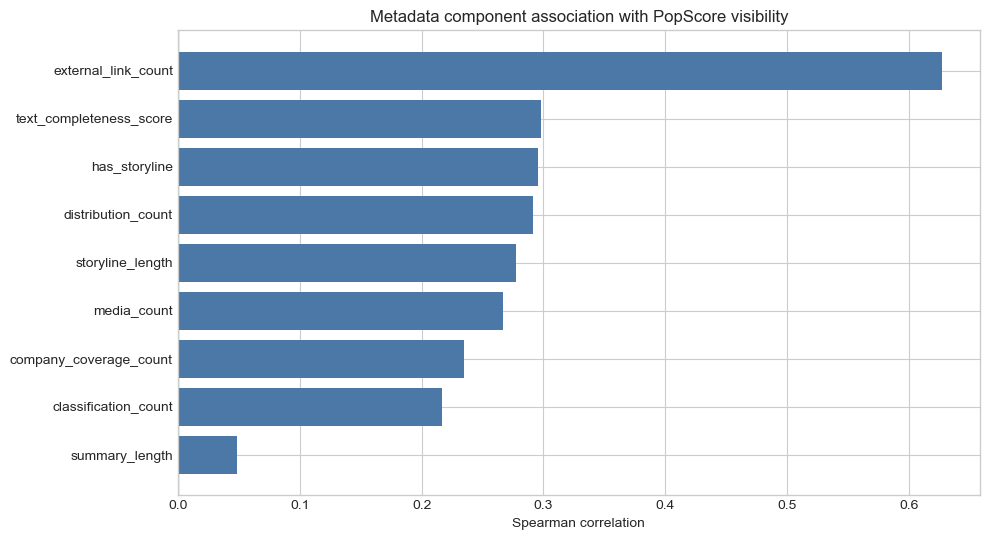

In [74]:
metadata_components = [
    "classification_count", "distribution_count", "company_coverage_count",
    "external_link_count", "media_count", "text_completeness_score",
    "summary_length", "storyline_length", "has_storyline",
]
metadata_rows = []
for component in metadata_components:
    scopes = [("all", diagnostic_game_base)]
    scopes.extend((cohort, group) for cohort, group in diagnostic_game_base.groupby("extraction_cohort"))
    for cohort, subset in scopes:
        n_visibility, visibility_corr, visibility_p = safe_correlation(
            subset[subset["popscore_available_flag"] == 1], component, "custom_interest_percentile", "spearman"
        )
        n_rating, rating_corr, rating_p = safe_correlation(
            subset[subset["rating_reliable_flag"] == 1], component, "total_rating", "spearman"
        )
        metadata_rows.append({
            "metadata_component": component,
            "extraction_cohort": cohort,
            "game_count": len(subset),
            "median_component_value": subset[component].median(),
            "popscore_correlation_n": n_visibility,
            "spearman_with_popscore_percentile": visibility_corr,
            "popscore_correlation_p_value": visibility_p,
            "popscore_correlation_status": "ok" if n_visibility >= MIN_CORRELATION_N and pd.notna(visibility_corr) else "insufficient sample",
            "rating_correlation_n": n_rating,
            "spearman_with_total_rating": rating_corr,
            "rating_correlation_p_value": rating_p,
            "rating_correlation_status": "ok" if n_rating >= MIN_CORRELATION_N and pd.notna(rating_corr) else "insufficient sample",
        })
metadata_component_summary = pd.DataFrame(metadata_rows)
metadata_component_summary["popscore_adjusted_p_value"] = metadata_component_summary.groupby("extraction_cohort")["popscore_correlation_p_value"].transform(benjamini_hochberg)
metadata_component_summary["rating_adjusted_p_value"] = metadata_component_summary.groupby("extraction_cohort")["rating_correlation_p_value"].transform(benjamini_hochberg)

metadata_analysis_base = diagnostic_game_base.merge(
    hidden_gem_eligible[["game_id", "hidden_gem_flag"]], on="game_id", how="left"
)
metadata_volume_rating_summary = (
    metadata_analysis_base[metadata_analysis_base["rating_reliable_flag"] == 1]
    .groupby(["metadata_volume_band", "extraction_cohort"], observed=True)
    .agg(
        game_count=("game_id", "nunique"),
        hidden_gem_eligible_games=("hidden_gem_flag", "count"),
        hidden_gem_count=("hidden_gem_flag", "sum"),
        median_total_rating=("total_rating", "median"),
        median_total_rating_count=("total_rating_count", "median"),
        high_rated_share=("high_rated_flag", "mean"),
    ).reset_index()
)
metadata_volume_rating_summary["hidden_gem_share"] = metadata_volume_rating_summary["hidden_gem_count"] / metadata_volume_rating_summary["hidden_gem_eligible_games"].replace(0, np.nan)
metadata_volume_visibility_summary = (
    diagnostic_game_base[diagnostic_game_base["popscore_available_flag"] == 1]
    .groupby(["metadata_volume_band", "extraction_cohort"], observed=True)
    .agg(
        game_count=("game_id", "nunique"),
        median_custom_interest_score=("custom_interest_score", "median"),
        median_custom_interest_percentile=("custom_interest_percentile", "median"),
    ).reset_index()
)
tables_to_export.update({
    "metadata_component_summary": metadata_component_summary,
    "metadata_volume_rating_summary": metadata_volume_rating_summary,
    "metadata_volume_visibility_summary": metadata_volume_visibility_summary,
})
display(metadata_component_summary)
display(metadata_volume_rating_summary)

component_plot = metadata_component_summary.query("extraction_cohort == 'all'").sort_values("spearman_with_popscore_percentile")
fig, ax = plt.subplots(figsize=(10, 5.5))
colors = ["#E45756" if value < 0 else "#4C78A8" for value in component_plot["spearman_with_popscore_percentile"].fillna(0)]
ax.barh(component_plot["metadata_component"], component_plot["spearman_with_popscore_percentile"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set(title="Metadata component association with PopScore visibility", xlabel="Spearman correlation", ylabel="")
plt.tight_layout()
plt.show()

## 12. Gameplay, perspective, multiplayer, and playtime diagnostics

Missing multiplayer records are treated as unknown rather than no support. Missing time-to-beat records are also unknown.

In [75]:
game_mode_membership = run_query("""
SELECT DISTINCT gmb.game_id, gm.name AS game_mode_name
FROM game_modes_bridge gmb JOIN game_modes gm ON gmb.game_mode_id = gm.game_mode_id;
""")
perspective_membership = run_query("""
SELECT DISTINCT gpp.game_id, pp.name AS player_perspective_name
FROM game_player_perspectives gpp
JOIN player_perspectives pp ON gpp.player_perspective_id = pp.player_perspective_id;
""")

game_mode_rating_summary = build_category_summary(game_mode_membership, "game_mode_name", 20)
player_perspective_rating_summary = build_category_summary(perspective_membership, "player_perspective_name", 20)

multiplayer_by_game = run_query("""
SELECT
    game_id,
    1 AS has_multiplayer_detail,
    MAX(CASE WHEN campaign_coop = 1 THEN 1 ELSE 0 END) AS has_campaign_coop,
    MAX(CASE WHEN online_coop = 1 THEN 1 ELSE 0 END) AS has_online_coop,
    MAX(CASE WHEN offline_coop = 1 THEN 1 ELSE 0 END) AS has_offline_coop,
    MAX(CASE WHEN split_screen = 1 THEN 1 ELSE 0 END) AS has_split_screen
FROM multiplayer_modes
GROUP BY game_id;
""")
multiplayer_known = (
    diagnostic_game_base.merge(multiplayer_by_game, on="game_id", how="inner")
    .merge(hidden_gem_eligible[["game_id", "hidden_gem_flag"]], on="game_id", how="left")
)
multiplayer_rows = []
for flag in ["has_campaign_coop", "has_online_coop", "has_offline_coop", "has_split_screen"]:
    for value, label in [(1, "Yes"), (0, "Recorded no")]:
        subset = multiplayer_known[multiplayer_known[flag] == value]
        multiplayer_rows.append({
            "multiplayer_feature": flag,
            "feature_value": label,
            "game_count": subset["game_id"].nunique(),
            "rating_reliable_games": int(subset["rating_reliable_flag"].sum()),
            "median_total_rating": subset.loc[subset["rating_reliable_flag"] == 1, "total_rating"].median(),
            "median_total_rating_count": subset.loc[subset["rating_reliable_flag"] == 1, "total_rating_count"].median(),
            "median_custom_interest_percentile": subset.loc[subset["popscore_available_flag"] == 1, "custom_interest_percentile"].median(),
            "high_rated_share": subset.loc[subset["rating_reliable_flag"] == 1, "high_rated_flag"].mean(),
            "hidden_gem_eligible_games": int(subset["hidden_gem_flag"].notna().sum()),
            "hidden_gem_count": subset["hidden_gem_flag"].sum(),
            "hidden_gem_share": subset["hidden_gem_flag"].mean(),
        })
multiplayer_support_rating_summary = pd.DataFrame(multiplayer_rows)
multiplayer_support_rating_summary["games_with_unknown_multiplayer_detail"] = len(diagnostic_game_base) - multiplayer_by_game["game_id"].nunique()

playtime = run_query("""
SELECT game_id, normally / 3600.0 AS normally_hours, "count" AS time_to_beat_count
FROM game_time_to_beats;
""")
playtime_base = (
    diagnostic_game_base.merge(playtime, on="game_id", how="left")
    .merge(hidden_gem_eligible[["game_id", "hidden_gem_flag"]], on="game_id", how="left")
)
playtime_base["playtime_band"] = pd.cut(
    playtime_base["normally_hours"],
    bins=[0, 5, 15, 30, 60, np.inf],
    labels=["Very short: 0-5 hours", "Short: 5-15 hours", "Medium: 15-30 hours", "Long: 30-60 hours", "Very long: 60+ hours"],
    include_lowest=True,
).astype("object").fillna("Unknown")
playtime_coverage_summary = (
    playtime_base.groupby(["playtime_band", "extraction_cohort"], observed=True)
    .agg(
        game_count=("game_id", "nunique"),
        hidden_gem_eligible_games=("hidden_gem_flag", "count"),
        hidden_gem_count=("hidden_gem_flag", "sum"),
        median_normally_hours=("normally_hours", "median"),
        median_custom_interest_percentile=("custom_interest_percentile", "median"),
    ).reset_index()
)
playtime_reliable_rating_summary = (
    playtime_base[playtime_base["rating_reliable_flag"] == 1]
    .groupby(["playtime_band", "extraction_cohort"], observed=True)
    .agg(
        rated_reliable_games=("game_id", "nunique"),
        median_total_rating=("total_rating", "median"),
        median_total_rating_count=("total_rating_count", "median"),
        high_rated_share=("high_rated_flag", "mean"),
    ).reset_index()
)
playtime_rating_summary = playtime_coverage_summary.merge(
    playtime_reliable_rating_summary,
    on=["playtime_band", "extraction_cohort"],
    how="left",
)
playtime_rating_summary["hidden_gem_share"] = playtime_rating_summary["hidden_gem_count"] / playtime_rating_summary["hidden_gem_eligible_games"].replace(0, np.nan)

tables_to_export.update({
    "game_mode_rating_summary": game_mode_rating_summary,
    "player_perspective_rating_summary": player_perspective_rating_summary,
    "multiplayer_support_rating_summary": multiplayer_support_rating_summary,
    "playtime_rating_summary": playtime_rating_summary,
})
display(game_mode_rating_summary)
display(player_perspective_rating_summary)
display(multiplayer_support_rating_summary)
display(playtime_rating_summary)

,game_mode_name,game_count,median_total_rating,mean_total_rating,rating_q1,rating_q3,median_total_rating_count,high_rated_count,high_rated_share,rating_iqr,comparison_cohort_games,popularity_cohort_games,quality_cohort_games,hidden_gem_eligible_games,hidden_gem_count,hidden_gem_share,low_sample_flag
5,Split screen,186,76.597,76.122,72.279,80.704,74.000,52.000,0.280,8.425,0,75,111,105,18,0.171,False
4,Single player,2376,76.416,75.654,71.090,81.358,66.000,749.000,0.315,10.269,27,982,1367,1313,218,0.166,False
3,Multiplayer,1195,75.388,74.532,70.395,80.673,72.000,328.000,0.274,10.278,13,555,627,602,92,0.153,False
1,Co-operative,817,75.087,74.360,70.388,80.150,77.000,211.000,0.258,9.761,7,396,414,403,52,0.129,False
2,Massively Multiplayer Online (MMO),112,71.291,70.853,65.789,76.758,64.000,19.000,0.170,10.969,1,71,40,40,7,0.175,False
0,Battle Royale,33,70.215,69.569,60.803,76.797,54.000,7.000,0.212,15.994,0,22,11,11,2,0.182,False


,player_perspective_name,game_count,median_total_rating,mean_total_rating,rating_q1,rating_q3,median_total_rating_count,high_rated_count,high_rated_share,rating_iqr,comparison_cohort_games,popularity_cohort_games,quality_cohort_games,hidden_gem_eligible_games,hidden_gem_count,hidden_gem_share,low_sample_flag
4,Text,100,78.397,77.478,71.508,83.316,48.500,41.000,0.410,11.808,1,35,64,63,17,0.270,False
3,Side view,565,77.349,76.631,72.264,81.641,55.000,191.000,0.338,9.377,6,199,360,341,69,0.202,False
1,Bird view / Isometric,574,76.961,76.544,71.900,82.232,59.000,202.000,0.352,10.332,4,207,363,350,72,0.206,False
6,Virtual Reality,85,76.625,74.845,68.991,82.407,68.000,29.000,0.341,13.416,0,36,49,49,11,0.224,False
2,First person,634,75.752,74.375,70.352,80.878,84.500,182.000,0.287,10.526,5,291,338,330,42,0.127,False
5,Third person,1026,75.545,75.017,70.515,81.133,82.500,308.000,0.300,10.618,8,476,542,518,56,0.108,False
0,Auditory,16,78.864,78.570,71.391,84.302,37.500,7.000,0.438,12.911,1,5,10,10,6,0.600,True


,multiplayer_feature,feature_value,game_count,rating_reliable_games,median_total_rating,median_total_rating_count,median_custom_interest_percentile,high_rated_share,hidden_gem_eligible_games,hidden_gem_count,hidden_gem_share,games_with_unknown_multiplayer_detail
0,has_campaign_coop,Yes,537,329,75.283,99.000,0.630,0.277,164,10.000,0.061,13164
1,has_campaign_coop,Recorded no,1299,564,75.725,90.000,0.596,0.301,297,39.000,0.131,13164
2,has_online_coop,Yes,860,495,74.948,101.000,0.661,0.259,237,18.000,0.076,13164
3,has_online_coop,Recorded no,976,398,76.628,84.000,0.543,0.334,224,31.000,0.138,13164
4,has_offline_coop,Yes,585,318,75.905,85.500,0.547,0.286,170,23.000,0.135,13164
5,has_offline_coop,Recorded no,1251,575,75.283,98.000,0.647,0.296,291,26.000,0.089,13164
6,has_split_screen,Yes,235,131,75.746,111.000,0.606,0.275,70,8.000,0.114,13164
7,has_split_screen,Recorded no,1601,762,75.615,90.000,0.608,0.295,391,41.000,0.105,13164


,playtime_band,extraction_cohort,game_count,hidden_gem_eligible_games,hidden_gem_count,median_normally_hours,median_custom_interest_percentile,rated_reliable_games,median_total_rating,median_total_rating_count,high_rated_share,hidden_gem_share
0,Long: 30-60 hours,comparison,3,0,0.000,40.000,0.000,NaN,NaN,NaN,NaN,NaN
1,Long: 30-60 hours,popularity,91,0,0.000,42.500,0.666,47.000,71.862,98.000,0.000,NaN
2,Long: 30-60 hours,quality,150,149,10.000,41.000,0.903,150.000,81.923,187.500,0.687,0.067
3,Medium: 15-30 hours,comparison,13,0,0.000,24.000,0.079,NaN,NaN,NaN,NaN,NaN
4,Medium: 15-30 hours,popularity,152,0,0.000,20.500,0.691,96.000,71.100,98.500,0.000,NaN
5,Medium: 15-30 hours,quality,185,183,14.000,20.802,0.894,185.000,81.737,196.000,0.632,0.077
6,Short: 5-15 hours,comparison,47,0,0.000,8.000,0.159,5.000,69.145,43.000,0.000,NaN
7,Short: 5-15 hours,popularity,341,0,0.000,8.833,0.618,199.000,71.005,75.000,0.000,NaN
8,Short: 5-15 hours,quality,318,312,40.000,9.000,0.817,318.000,80.577,116.000,0.547,0.128
9,Unknown,comparison,10420,0,0.000,NaN,0.056,20.000,64.142,28.000,0.000,NaN


## 13. PopScore coverage and popularity primitive diagnostics

Primitive values are compared only within source/type combinations. They are not averaged across incompatible signals. Source/type correlations with fewer than 25 complete observations are marked as insufficient.

In [76]:
popularity_primitive_coverage = run_query("""
SELECT
    COALESCE(v.popularity_source, 'Unknown source') AS popularity_source,
    COALESCE(v.popularity_type, 'Unknown type') AS popularity_type,
    COUNT(DISTINCT v.game_id) AS games_with_latest_signal,
    COUNT(*) AS latest_signal_rows,
    MIN(v.calculated_at_iso) AS earliest_calculated_at,
    MAX(v.calculated_at_iso) AS latest_calculated_at
FROM vw_game_popscore_latest v
GROUP BY COALESCE(v.popularity_source, 'Unknown source'), COALESCE(v.popularity_type, 'Unknown type')
ORDER BY games_with_latest_signal DESC;
""")
popularity_signal_coverage = (
    diagnostic_game_base.groupby(["release_year", "extraction_cohort"])
    .agg(
        game_count=("game_id", "nunique"),
        popscore_covered_games=("popscore_available_flag", "sum"),
        median_custom_interest_score=("custom_interest_score", "median"),
        median_custom_interest_percentile=("custom_interest_percentile", "median"),
    )
    .reset_index()
)
popularity_signal_coverage["popscore_coverage_rate"] = popularity_signal_coverage["popscore_covered_games"] / popularity_signal_coverage["game_count"]

latest_primitives = run_query("""
SELECT
    v.game_id,
    v.popularity_source,
    v.popularity_type,
    v.value,
    g.total_rating,
    g.total_rating_count,
    xc.cohort AS extraction_cohort,
    g.release_year
FROM vw_game_popscore_latest v
JOIN games g ON v.game_id = g.game_id
JOIN extraction_cohorts xc ON v.game_id = xc.game_id;
""")

primitive_rows = []
for (source, signal_type), group in latest_primitives.groupby(["popularity_source", "popularity_type"], dropna=False):
    n_count, corr_count, p_count = safe_correlation(group, "value", "total_rating_count", "spearman")
    n_rating, corr_rating, p_rating = safe_correlation(group, "value", "total_rating", "spearman")
    primitive_rows.append({
        "popularity_source": source,
        "popularity_type": signal_type,
        "game_count": group["game_id"].nunique(),
        "rating_count_correlation_n": n_count,
        "spearman_with_total_rating_count": corr_count,
        "rating_count_p_value": p_count,
        "rating_count_correlation_status": "ok" if n_count >= MIN_CORRELATION_N and pd.notna(corr_count) else "insufficient sample",
        "rating_correlation_n": n_rating,
        "spearman_with_total_rating": corr_rating,
        "rating_p_value": p_rating,
        "rating_correlation_status": "ok" if n_rating >= MIN_CORRELATION_N and pd.notna(corr_rating) else "insufficient sample",
    })
popularity_type_rating_count_correlation = pd.DataFrame(primitive_rows)
popularity_type_rating_count_correlation["rating_count_adjusted_p_value"] = benjamini_hochberg(popularity_type_rating_count_correlation["rating_count_p_value"])
popularity_type_rating_count_correlation["rating_adjusted_p_value"] = benjamini_hochberg(popularity_type_rating_count_correlation["rating_p_value"])

tables_to_export.update({
    "popularity_signal_coverage": popularity_signal_coverage,
    "popularity_primitive_coverage": popularity_primitive_coverage,
    "popularity_type_rating_count_correlation": popularity_type_rating_count_correlation,
})
display(popularity_signal_coverage)
display(popularity_primitive_coverage)
display(popularity_type_rating_count_correlation)

,release_year,extraction_cohort,game_count,popscore_covered_games,median_custom_interest_score,median_custom_interest_percentile,popscore_coverage_rate
0,2010,comparison,723,9,0.000,0.000,0.012
1,2010,popularity,200,200,0.000,0.154,1.000
2,2010,quality,77,74,0.000,0.723,0.961
3,2011,comparison,714,11,0.000,0.000,0.015
4,2011,popularity,200,200,0.000,0.169,1.000
5,2011,quality,86,79,0.000,0.582,0.919
6,2012,comparison,705,17,0.000,0.025,0.024
7,2012,popularity,200,200,0.000,0.220,1.000
8,2012,quality,95,89,0.000,0.661,0.937
9,2013,comparison,702,35,0.000,0.025,0.050


,popularity_source,popularity_type,games_with_latest_signal,latest_signal_rows,earliest_calculated_at,latest_calculated_at
0,IGDB,Played,7949,7949,2026-06-20T01:12:06+00:00,2026-06-20T01:12:06+00:00
1,Steam,Negative Reviews,7473,7473,2026-06-19T16:22:41+00:00,2026-06-19T16:22:41+00:00
2,Steam,24hr Peak Players,7462,7462,2026-06-15T15:56:49+00:00,2026-06-15T15:56:49+00:00
3,Steam,Postitive Reviews,7462,7462,2026-06-15T16:03:14+00:00,2026-06-15T16:03:14+00:00
4,Steam,Total Reviews,7462,7462,2026-06-15T15:56:49+00:00,2026-06-15T15:56:49+00:00
5,IGDB,Want to Play,7267,7267,2026-06-20T01:12:25+00:00,2026-06-20T01:12:25+00:00
6,IGDB,Playing,5102,5102,2026-06-20T01:03:40+00:00,2026-06-20T01:03:40+00:00
7,IGDB,Visits,5027,5027,2026-06-20T00:03:33+00:00,2026-06-20T00:03:33+00:00
8,Twitch,24hr Hours Watched,3415,3415,2026-06-19T20:57:33+00:00,2026-06-19T20:57:33+00:00
9,Steam,Global Top Sellers,1821,1821,2026-06-19T03:48:22+00:00,2026-06-19T03:48:22+00:00


,popularity_source,popularity_type,game_count,rating_count_correlation_n,spearman_with_total_rating_count,rating_count_p_value,rating_count_correlation_status,rating_correlation_n,spearman_with_total_rating,rating_p_value,rating_correlation_status,rating_count_adjusted_p_value,rating_adjusted_p_value
0,IGDB,Played,7949,5755,0.955,0.000,ok,5755,0.381,0.000,ok,0.000,0.000
1,IGDB,Playing,5102,4517,0.645,0.000,ok,4517,0.315,0.000,ok,0.000,0.000
2,IGDB,Visits,5027,4039,0.505,0.000,ok,4039,0.223,0.000,ok,0.000,0.000
3,IGDB,Want to Play,7267,5553,0.735,0.000,ok,5553,0.369,0.000,ok,0.000,0.000
4,Steam,24hr Peak Players,7462,4571,0.692,0.000,ok,4571,0.428,0.000,ok,0.000,0.000
5,Steam,Global Top Sellers,1821,1758,0.324,0.000,ok,1758,0.129,0.000,ok,0.000,0.000
6,Steam,Most Wishlisted Upcoming,7,3,NaN,NaN,insufficient sample,3,NaN,NaN,insufficient sample,NaN,NaN
7,Steam,Negative Reviews,7473,4581,0.757,0.000,ok,4581,0.255,0.000,ok,0.000,0.000
8,Steam,Postitive Reviews,7462,4571,0.823,0.000,ok,4571,0.460,0.000,ok,0.000,0.000
9,Steam,Total Reviews,7462,4571,0.821,0.000,ok,4571,0.428,0.000,ok,0.000,0.000


## 14. Combined adjusted association summary

This consolidates the cohort- and release-year-adjusted diagnostic estimates. Predictive, prescriptive, and RAG work remains outside this notebook.

In [77]:
effect_frames = [genre_effects, theme_effects, genre_theme_effects, developer_effects, publisher_effects]
cohort_adjusted_association_summary = pd.concat(
    [frame for frame in effect_frames if frame is not None and not frame.empty],
    ignore_index=True,
)
cohort_adjusted_association_summary = cohort_adjusted_association_summary.sort_values(
    ["category_type", "adjusted_p_value", "odds_ratio"], ascending=[True, True, False]
)
tables_to_export.update({
    "cohort_adjusted_association_summary": cohort_adjusted_association_summary,
})
display(cohort_adjusted_association_summary.head(40))

,category_type,category_name,estimand,category_game_count,quality_games_with_category,comparison_games_with_category,odds_ratio,odds_ratio_ci_low,odds_ratio_ci_high,p_value,model_status,adjusted_p_value,fdr_significant
256,developer,EA Canada,quality-cohort enrichment vs residual comparis...,17,14,3,38.083,11.130,130.308,0.000,ok,0.000,True
257,developer,Capcom,quality-cohort enrichment vs residual comparis...,20,12,8,11.485,4.631,28.484,0.000,ok,0.000,True
258,developer,Visual Concepts,quality-cohort enrichment vs residual comparis...,13,10,3,25.975,7.152,94.332,0.000,ok,0.000,True
259,developer,Ubisoft Montreal,quality-cohort enrichment vs residual comparis...,16,15,1,121.300,16.421,896.059,0.000,ok,0.000,True
260,developer,Codemasters,quality-cohort enrichment vs residual comparis...,12,11,1,81.682,10.971,608.128,0.000,ok,0.000,True
261,developer,Bandai Namco Studios,quality-cohort enrichment vs residual comparis...,12,8,4,15.090,4.358,52.249,0.000,ok,0.000,True
262,developer,Nintendo,quality-cohort enrichment vs residual comparis...,18,9,9,7.786,3.059,19.814,0.000,ok,0.000,True
263,developer,Omega Force,quality-cohort enrichment vs residual comparis...,10,7,3,17.213,4.629,64.006,0.000,ok,0.000,True
264,developer,Atlus,quality-cohort enrichment vs residual comparis...,13,12,1,85.458,10.733,680.409,0.000,ok,0.000,True
265,developer,Arc System Works,quality-cohort enrichment vs residual comparis...,18,9,9,7.142,2.830,18.028,0.000,ok,0.000,True


## 15. Diagnostic takeaways and limitations

The following table is generated from the notebook results so the evidence remains auditable.

In [78]:
def overall_spearman(table):
    row = table.query("scope_type == 'overall' and method == 'spearman'")
    return float(row.iloc[0]["coefficient"]) if not row.empty else np.nan


quality_popscore_rho = overall_spearman(quality_popscore_correlation)
quality_activity_rho = overall_spearman(quality_rating_activity_correlation)
platform_visibility_rho = overall_spearman(platform_visibility_correlation)
balanced_hidden_gem_count = int(hidden_gem_sensitivity_analysis.loc[hidden_gem_sensitivity_analysis["variant"] == "Balanced", "hidden_gem_count"].iloc[0])
significant_effects = int(cohort_adjusted_association_summary["fdr_significant"].fillna(False).sum())
user_critic_spearman = float(user_critic_agreement_summary.loc[user_critic_agreement_summary["metric"] == "user_critic_spearman_correlation", "value"].iloc[0])

diagnostic_takeaways = pd.DataFrame([
    {
        "takeaway_id": 1,
        "finding": "Rating quality, rating activity, and PopScore visibility are distinct signals.",
        "evidence": f"Quality-PopScore Spearman rho={quality_popscore_rho:.3f}; quality-activity rho={quality_activity_rho:.3f}.",
        "interpretation": "Keep quality, confidence/activity, and visibility separate.",
    },
    {
        "takeaway_id": 2,
        "finding": "Low-visibility, high-quality candidates were identified within the quality cohort.",
        "evidence": f"{balanced_hidden_gem_count} quality-cohort games satisfy rating >= {QUALITY_THRESHOLD}, reliable evidence, main-game, PopScore-known, and within-year quality-cohort visibility <= {HIDDEN_GEM_VISIBILITY_PERCENTILE:.0%}.",
        "interpretation": "The list is an auditable within-sample diagnostic artifact, not a market-wide hidden-gem estimate or prescriptive ranking score.",
    },
    {
        "takeaway_id": 3,
        "finding": "Some categories are enriched in the quality cohort relative to the residual comparison cohort.",
        "evidence": f"{significant_effects} enrichment tests are significant after Benjamini-Hochberg correction.",
        "interpretation": "These reflect the curated extraction design, not direct quality effects, causal effects, or market prevalence estimates.",
    },
    {
        "takeaway_id": 4,
        "finding": "Platform reach and PopScore visibility can be compared separately from rating quality.",
        "evidence": f"Platform-count versus PopScore-percentile Spearman rho={platform_visibility_rho:.3f}.",
        "interpretation": "Platform count is a reach signal and may also reflect commercial visibility or release strategy.",
    },
    {
        "takeaway_id": 5,
        "finding": "User and critic reception are related but not identical.",
        "evidence": f"User-versus-critic Spearman rho={user_critic_spearman:.3f}; disagreement cases are exported separately.",
        "interpretation": "Retain user-only, critic-only, and combined ratings as separate fields.",
    },
])

tables_to_export["diagnostic_takeaways"] = diagnostic_takeaways
display(diagnostic_takeaways)

display(Markdown("""
### Limitations

- The dataset is a curated yearly cohort sample, not the full IGDB catalog or video game market.
- Quality and visibility games are deliberately oversampled; unadjusted full-sample shares are not prevalence estimates.
- Hidden-gem candidates are low-visibility games within the curated quality cohort, not estimates of hidden gems in the full market.
- Quality-versus-comparison odds ratios measure cohort enrichment; the comparison cohort excludes quality-selected and popularity-selected games.
- Ratings and metadata are observational and may reflect audience size, platform reach, historical popularity, or documentation bias.
- Missing PopScore means visibility unknown, not low visibility.
- Games can belong to multiple genres, themes, platforms, modes, and companies; category counts overlap.
- Multiple category tests use effect sizes, confidence intervals, and false-discovery-rate correction, but residual confounding remains.
- All findings are associations, not causal claims.
"""))

,takeaway_id,finding,evidence,interpretation
0,1,"Rating quality, rating activity, and PopScore ...",Quality-PopScore Spearman rho=0.331; quality-a...,"Keep quality, confidence/activity, and visibil..."
1,2,"Low-visibility, high-quality candidates were i...","229 quality-cohort games satisfy rating >= 80,...",The list is an auditable within-sample diagnos...
2,3,Some categories are enriched in the quality co...,273 enrichment tests are significant after Ben...,"These reflect the curated extraction design, n..."
3,4,Platform reach and PopScore visibility can be ...,Platform-count versus PopScore-percentile Spea...,Platform count is a reach signal and may also ...
4,5,User and critic reception are related but not ...,User-versus-critic Spearman rho=0.696; disagre...,"Retain user-only, critic-only, and combined ra..."



### Limitations

- The dataset is a curated yearly cohort sample, not the full IGDB catalog or video game market.
- Quality and visibility games are deliberately oversampled; unadjusted full-sample shares are not prevalence estimates.
- Hidden-gem candidates are low-visibility games within the curated quality cohort, not estimates of hidden gems in the full market.
- Quality-versus-comparison odds ratios measure cohort enrichment; the comparison cohort excludes quality-selected and popularity-selected games.
- Ratings and metadata are observational and may reflect audience size, platform reach, historical popularity, or documentation bias.
- Missing PopScore means visibility unknown, not low visibility.
- Games can belong to multiple genres, themes, platforms, modes, and companies; category counts overlap.
- Multiple category tests use effect sizes, confidence intervals, and false-discovery-rate correction, but residual confounding remains.
- All findings are associations, not causal claims.


## 16. Export diagnostic outputs

In [79]:
required_outputs = [
    "diagnostic_dataset_snapshot", "diagnostic_game_base", "diagnostic_rating_reliable_base",
    "quality_popscore_correlation", "quality_rating_activity_correlation", "rating_band_popscore_summary",
    "hidden_gem_candidates", "hidden_gem_threshold_summary", "hidden_gem_sensitivity_analysis",
    "user_critic_agreement_summary", "user_critic_gap_games",
    "genre_rating_summary", "theme_rating_summary", "genre_theme_rating_summary",
    "platform_reach_summary", "metadata_component_summary",
    "cohort_adjusted_association_summary", "diagnostic_takeaways",
]
missing_outputs = sorted(set(required_outputs) - set(tables_to_export))
if missing_outputs:
    raise KeyError(f"Required outputs were not created: {missing_outputs}")

if EXPORT_TABLES:
    export_rows = []
    for table_name, frame in tables_to_export.items():
        output_path = OUTPUT_DIR / f"{table_name}.csv"
        frame.to_csv(output_path, index=False)
        export_rows.append({
            "output_name": table_name,
            "row_count": len(frame),
            "file": str(output_path.relative_to(ROOT_DIR)),
        })
    export_manifest = pd.DataFrame(export_rows).sort_values("output_name").reset_index(drop=True)
    export_manifest.to_csv(OUTPUT_DIR / "diagnostic_export_manifest.csv", index=False)
    display(export_manifest)
else:
    print("CSV export skipped. Set EXPORT_TABLES = True to write diagnostic outputs.")

,output_name,row_count,file
0,cohort_adjusted_association_summary,378,data\analytics\diagnostic\cohort_adjusted_asso...
1,developer_rating_summary,1548,data\analytics\diagnostic\developer_rating_sum...
2,diagnostic_dataset_snapshot,11,data\analytics\diagnostic\diagnostic_dataset_s...
3,diagnostic_game_base,15000,data\analytics\diagnostic\diagnostic_game_base...
4,diagnostic_rating_reliable_base,2498,data\analytics\diagnostic\diagnostic_rating_re...
5,diagnostic_takeaways,5,data\analytics\diagnostic\diagnostic_takeaways...
6,game_mode_rating_summary,6,data\analytics\diagnostic\game_mode_rating_sum...
7,genre_rating_summary,23,data\analytics\diagnostic\genre_rating_summary...
8,genre_theme_rating_summary,400,data\analytics\diagnostic\genre_theme_rating_s...
9,hidden_gem_by_genre,23,data\analytics\diagnostic\hidden_gem_by_genre.csv


In [80]:
conn.close()
print("Diagnostic analytics notebook completed and database connection closed.")

Diagnostic analytics notebook completed and database connection closed.
